In [39]:
## Model evaluation — test-set profit comparison

"""
Load coordinated RL, myopic, and single-market rolling-intrinsic **daily** `profit.csv` files and merge on **delivery calendar day** (Europe/Berlin). The RL file defines which days are in scope.

**Choose the RL run** with `SELECTED_MODEL` (folder `output/coordinated_multi_market/logging/<id>/`). Training ranges for each id are in `evaluation/rl_model_registry.py`.

Run from the **repository root** or from `evaluation/` (paths adjusted in the next cell).

"""

'\nLoad coordinated RL, myopic, and single-market rolling-intrinsic **daily** `profit.csv` files and merge on **delivery calendar day** (Europe/Berlin). The RL file defines which days are in scope.\n\n**Choose the RL run** with `SELECTED_MODEL` (folder `output/coordinated_multi_market/logging/<id>/`). Training ranges for each id are in `evaluation/rl_model_registry.py`.\n\nRun from the **repository root** or from `evaluation/` (paths adjusted in the next cell).\n\n'

In [40]:
# --- only switch you need for coordinated RL outputs ---
SELECTED_MODEL = "8"  # "0" … "5"; see evaluation.rl_model_registry.RL_MODEL_REGISTRY

from pathlib import Path
import sys

import os
folder = "plots_rl_model_eval"
os.makedirs(folder, exist_ok=True)

_root = Path.cwd().resolve()
if _root.name == "evaluation":
    sys.path.insert(0, str(_root.parent))
else:
    sys.path.insert(0, str(_root))

import pandas as pd

from evaluation.merge_test_profits import build_test_comparison_df, default_paths_bs15
from evaluation.rl_model_registry import get_rl_model_spec, registry_as_dataframe

spec = get_rl_model_spec(SELECTED_MODEL)
print(spec.model_number, spec.describe_training())

paths = default_paths_bs15(SELECTED_MODEL)
from IPython.display import display

display(registry_as_dataframe())
paths

8 01.01.2019–31.03.2021 (Europe/Berlin)


,model_number,train_start,train_end_inclusive,train_end_exclusive,tensorboard_run_subdir
0,0,2019-01-01 00:00:00+01:00,2021-03-31 00:00:00+02:00,2021-04-01 00:00:00+02:00,PPO_0_1
1,1,2019-01-01 00:00:00+01:00,2021-03-31 00:00:00+02:00,2021-04-01 00:00:00+02:00,PPO_1_0
2,2,2023-01-01 00:00:00+01:00,2025-03-31 00:00:00+02:00,2025-04-01 00:00:00+02:00,PPO_2_1
3,3,2023-01-01 00:00:00+01:00,2025-03-31 00:00:00+02:00,2025-04-01 00:00:00+02:00,PPO_3_0
4,4,2019-01-01 00:00:00+01:00,2024-09-30 00:00:00+02:00,2024-10-01 00:00:00+02:00,PPO_4_1
5,5,2019-01-01 00:00:00+01:00,2024-09-30 00:00:00+02:00,2024-10-01 00:00:00+02:00,PPO_5_0
6,6,2019-01-01 00:00:00+01:00,2021-03-31 00:00:00+02:00,2021-04-01 00:00:00+02:00,PPO_6_0
7,7,2019-01-01 00:00:00+01:00,2021-03-31 00:00:00+02:00,2021-04-01 00:00:00+02:00,PPO_7_1
8,8,2019-01-01 00:00:00+01:00,2021-03-31 00:00:00+02:00,2021-04-01 00:00:00+02:00,PPO_8_0
9,9,2019-01-01 00:00:00+01:00,2021-03-31 00:00:00+02:00,2021-04-01 00:00:00+02:00,PPO_9_1


{'model_number': '8',
 'train_start': '2019-01-01T00:00:00+01:00',
 'train_end_inclusive': '2021-03-31T00:00:00+02:00',
 'rl': '/Users/timflaschel/Documents/GitHub/BessBidder1/output/coordinated_multi_market/logging/8/rolling_intrinsic_intelligently_stacked_on_day_ahead_qh/bs15cr1rto0.86mc365mt10/profit.csv',
 'myopic': '/Users/timflaschel/Documents/GitHub/BessBidder1/output/myopic_multi_market/rolling_intrinsic_stacked_on_day_ahead_qh/bs15cr1rto0.86mc365mt10/profit.csv',
 'single_glob': 'output/single_market/rolling_intrinsic/ri_basic/qh/*/bs15cr1rto0.86mc365mt10/profit.csv',
 'single_file': '/Users/timflaschel/Documents/GitHub/BessBidder1/output/single_market/profit.csv'}

In [41]:
from pathlib import Path

# Prefer consolidated output/single_market/profit.csv; fall back to per-year glob if missing.
_single_csv = Path(paths["single_file"])
if _single_csv.is_file():
    df_test = build_test_comparison_df(
        paths["rl"],
        paths["myopic"],
        single_market_profit_csv=paths["single_file"],
    )
else:
    try:
        df_test = build_test_comparison_df(
            paths["rl"],
            paths["myopic"],
            single_market_glob=paths["single_glob"],
        )
    except FileNotFoundError:
        df_test = build_test_comparison_df(
            paths["rl"],
            paths["myopic"],
            single_market_profit_csv=paths["single_file"],
        )

df_test.head(10)

,delivery_day,day_rl,profit_rl_coordinated,profit_myopic,profit_single_market_ri
0,2021-04-01 00:00:00+02:00,2021-04-01 00:00:00+02:00,93.268093,92.200414,106.400831
1,2021-04-02 00:00:00+02:00,2021-04-02 00:00:00+02:00,171.773142,171.773142,160.882299
2,2021-04-03 00:00:00+02:00,2021-04-03 00:00:00+02:00,106.082374,108.628091,92.382040
3,2021-04-04 00:00:00+02:00,2021-04-04 00:00:00+02:00,138.618575,135.974138,143.309281
4,2021-04-05 00:00:00+02:00,2021-04-05 00:00:00+02:00,240.452761,246.913258,283.404847
5,2021-04-06 00:00:00+02:00,2021-04-06 00:00:00+02:00,283.285205,277.790859,275.327106
6,2021-04-07 00:00:00+02:00,2021-04-07 00:00:00+02:00,131.325692,137.939105,133.295551
7,2021-04-08 00:00:00+02:00,2021-04-08 00:00:00+02:00,126.484956,122.879300,126.882185
8,2021-04-09 00:00:00+02:00,2021-04-09 00:00:00+02:00,102.229895,94.549413,90.287894
9,2021-04-10 00:00:00+02:00,2021-04-10 00:00:00+02:00,128.785421,128.785421,116.464835


In [42]:
# Coverage check: baselines should have rows for each RL test day
summary = pd.DataFrame(
    {
        "rows": [len(df_test)],
        "myopic_missing": [df_test["profit_myopic"].isna().sum()],
        "single_market_missing": [df_test["profit_single_market_ri"].isna().sum()],
    }
)
summary

,rows,myopic_missing,single_market_missing
0,183,0,0


### Brute-force upper bound (per-day `summary_*.csv`)

For each test `delivery_day`, load `coordinated_market_upper_bound_analysis/results_merged/summary_YYYY-MM-DD.csv` and add **max / median / q75 / q90** of the `profit` column across all scenarios in that file.

For many repeated analyses you can later run `build_brute_force_long_cache()` once (see `evaluation/brute_force_summary_stats.py`).

In [43]:
from evaluation.brute_force_summary_stats import attach_brute_force_stats, default_results_merged_dir

df_test_bf = attach_brute_force_stats(df_test, on_missing="warn")
df_test_bf.head()

,delivery_day,day_rl,profit_rl_coordinated,profit_myopic,profit_single_market_ri,theoretical_max_profit,brute_median_profit,brute_q075_profit,brute_q090_profit,theoretical_max_da_profit,brute_median_da_profit,brute_q075_da_profit,brute_q090_da_profit,theoretical_max_idc_profit,brute_median_idc_profit,brute_q075_idc_profit,brute_q090_idc_profit
0,2021-04-01 00:00:00+02:00,2021-04-01 00:00:00+02:00,93.268093,92.200414,106.400831,117.956864,99.522368,107.708899,111.287624,1.0754,11.6892,-10.8400,-27.4830,116.881464,87.833168,118.548899,138.770624
1,2021-04-02 00:00:00+02:00,2021-04-02 00:00:00+02:00,171.773142,171.773142,160.882299,192.907218,163.095904,174.214762,179.882205,-4.7018,-68.3846,13.8792,-24.1200,197.609018,231.480504,160.335562,204.002205
2,2021-04-03 00:00:00+02:00,2021-04-03 00:00:00+02:00,106.082374,108.628091,92.382040,115.858681,102.532409,106.568025,110.084432,-23.9606,-5.4816,5.8728,-2.8462,139.819281,108.014009,100.695225,112.930632
3,2021-04-04 00:00:00+02:00,2021-04-04 00:00:00+02:00,138.618575,135.974138,143.309281,176.436141,143.399315,151.559513,160.443223,-38.6614,-38.1428,-11.1732,10.6368,215.097541,181.542115,162.732713,149.806423
4,2021-04-05 00:00:00+02:00,2021-04-05 00:00:00+02:00,240.452761,246.913258,283.404847,339.618408,278.572836,293.774693,310.976521,11.1652,-15.3678,48.0990,6.1052,328.453208,293.940636,245.675693,304.871321


### Day-ahead vs intraday split (from trades)

Rolling-intrinsic **total** daily € in `profit_*` columns come from `profit.csv`. **DA** vs **IDC** sums use the same rule as elsewhere: trades with **execution** at **13:00** (Europe/Berlin) on **delivery day - 1** count as day-ahead; all other rows are intraday (`evaluation.da_idc_profit_enrichment`, same logic as `daily_da_idc_profit_from_trades_file`).

- **`df_test_bf_da_idc`**: `df_test_bf` plus `profit_*_da`, `profit_*_idc`, `profit_*_da_share`, `profit_*_idc_share` for RL, myopic, and single-market columns (when trades exist).
- **`df_test_bf_day_ahead`** / **`df_test_bf_intraday`**: copies with the **same columns as `df_test_bf`**, but the three daily profit columns are replaced by the DA-only or IDC-only amounts; brute-force columns are unchanged.

To enrich a standalone `profit.csv` once on disk, use `enrich_rolling_intrinsic_profit_csv(profit_csv, trades_dir, output_path=...)`.


In [44]:
from pathlib import Path

from evaluation.da_idc_profit_enrichment import (
    attach_da_idc_to_comparison_df,
    day_ahead_profit_view,
    intraday_profit_view,
)
from evaluation.rl_model_registry import paths_for_coordinated_model

_repo = Path.cwd().resolve()
if _repo.name == "evaluation":
    _repo = _repo.parent

_paths_da = paths_for_coordinated_model(SELECTED_MODEL, repo_root=_repo)
_single_trades = _repo / "output" / "single_market" / "trades"

df_test_bf_da_idc = attach_da_idc_to_comparison_df(
    df_test_bf,
    rl_trades_dir=_paths_da["trades_dir"],
    myopic_trades_dir=_paths_da["myopic_trades_dir"],
    single_market_trades_dir=_single_trades,
    on_missing="warn",
)

df_test_bf_day_ahead = day_ahead_profit_view(df_test_bf_da_idc)
df_test_bf_intraday = intraday_profit_view(df_test_bf_da_idc)

df_test_bf_da_idc.head()


,delivery_day,day_rl,profit_rl_coordinated,profit_myopic,profit_single_market_ri,theoretical_max_profit,brute_median_profit,brute_q075_profit,brute_q090_profit,theoretical_max_da_profit,...,profit_rl_coordinated_da_share,profit_rl_coordinated_idc_share,profit_myopic_da,profit_myopic_idc,profit_myopic_da_share,profit_myopic_idc_share,profit_single_market_ri_da,profit_single_market_ri_idc,profit_single_market_ri_da_share,profit_single_market_ri_idc_share
0,2021-04-01 00:00:00+02:00,2021-04-01 00:00:00+02:00,93.268093,92.200414,106.400831,117.956864,99.522368,107.708899,111.287624,1.0754,...,0.26,0.74,27.46,64.740414,0.30,0.70,0.0,106.400831,0.0,1.0
1,2021-04-02 00:00:00+02:00,2021-04-02 00:00:00+02:00,171.773142,171.773142,160.882299,192.907218,163.095904,174.214762,179.882205,-4.7018,...,0.36,0.64,62.57,109.203142,0.36,0.64,0.0,160.882299,0.0,1.0
2,2021-04-03 00:00:00+02:00,2021-04-03 00:00:00+02:00,106.082374,108.628091,92.382040,115.858681,102.532409,106.568025,110.084432,-23.9606,...,0.40,0.60,49.48,59.148091,0.46,0.54,0.0,92.382040,0.0,1.0
3,2021-04-04 00:00:00+02:00,2021-04-04 00:00:00+02:00,138.618575,135.974138,143.309281,176.436141,143.399315,151.559513,160.443223,-38.6614,...,0.33,0.67,47.35,88.624138,0.35,0.65,0.0,143.309281,0.0,1.0
4,2021-04-05 00:00:00+02:00,2021-04-05 00:00:00+02:00,240.452761,246.913258,283.404847,339.618408,278.572836,293.774693,310.976521,11.1652,...,0.30,0.70,71.20,175.713258,0.29,0.71,0.0,283.404847,0.0,1.0


In [45]:
from evaluation.da_idc_profit_enrichment import profit_comparison_summary

df_profit_summary = profit_comparison_summary(df_test_bf_da_idc)
df_profit_summary.round(2)


,Coordinated multi-market,Myopic multi-market,Single market (rolling intrinsic),Daily max (brute),Daily median (brute),Daily q75 (brute),Daily q90 (brute)
mean_total_profit,142.00,140.19,142.09,168.19,141.56,148.69,154.66
mean_da_profit,49.38,53.11,0.00,-17.02,-6.52,-6.22,-7.70
mean_idc_profit,92.63,87.08,142.09,185.20,148.08,154.91,162.35
total_profit_std,64.14,65.89,64.47,76.40,63.92,66.88,69.83


In [46]:
df_profit_summary.columns

Index(['Coordinated multi-market', 'Myopic multi-market',
       'Single market (rolling intrinsic)', 'Daily max (brute)',
       'Daily median (brute)', 'Daily q75 (brute)', 'Daily q90 (brute)'],
      dtype='object')

In [47]:
df_test_bf.describe()

,profit_rl_coordinated,profit_myopic,profit_single_market_ri,theoretical_max_profit,brute_median_profit,brute_q075_profit,brute_q090_profit,theoretical_max_da_profit,brute_median_da_profit,brute_q075_da_profit,brute_q090_da_profit,theoretical_max_idc_profit,brute_median_idc_profit,brute_q075_idc_profit,brute_q090_idc_profit
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000
mean,142.002066,140.191729,142.085553,168.186423,141.555887,148.690287,154.656442,-17.018431,-6.524199,-6.224482,-7.695024,185.204854,148.080086,154.914769,162.351466
std,64.144198,65.891204,64.468455,76.396617,63.919027,66.876565,69.831677,40.593274,28.321300,28.638521,30.382936,86.851653,68.959084,71.203206,72.251276
min,60.646584,54.627816,55.617982,75.914817,60.951446,64.875139,69.520519,-195.280000,-108.000000,-158.070000,-121.610000,62.966388,50.789070,63.441655,64.975671
25%,96.744985,92.254630,96.328620,113.538239,95.761973,100.553745,103.998213,-28.503500,-16.692800,-16.887500,-18.025100,119.376916,96.124000,106.562700,107.419572
50%,122.015782,120.253871,122.638870,146.193759,121.807472,127.683971,133.524072,-11.927200,-3.758800,-6.009000,-3.080000,165.201269,124.511680,133.104272,142.325140
75%,170.194005,165.646434,173.645900,199.565942,172.451297,179.035097,187.913079,5.205800,8.774800,8.630300,9.139000,226.402570,184.492897,184.766042,199.741100
max,370.463733,370.463733,349.342339,430.603454,351.032327,361.708338,397.656817,103.628400,105.728600,54.652800,75.402000,569.354069,364.640117,394.782503,458.433217


### Cumulative profit + SoC (coordinated RL, test days)

**Left:** stacked **cumulative** profit (€): day-ahead trades (`execution_time` hour == 13 Berlin) vs intraday, summed from each row’s `profit` in `trades/trades_YYYY-MM-DD.csv` (same colour/hatch idea as your thesis reference: teal DA, pink IDC).

**Right:** mean **DA** vs **actual** SoC bands (96×15 min delivery time), as before.

Set **`SOC_Q_LOW`** / **`SOC_Q_HIGH`** in the code cell; implementation: `evaluation.coordinated_rl_test_plots`.


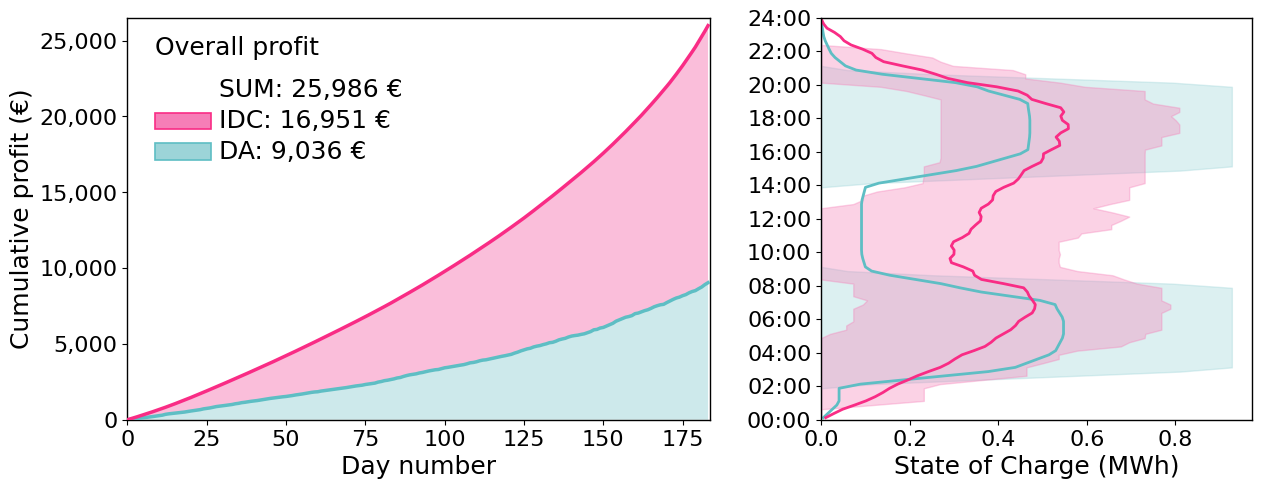

In [48]:
import matplotlib.pyplot as plt
from evaluation.coordinated_rl_test_plots import coordinated_rl_cumulative_profit_and_soc_figure

plot_name = "coordinated_rl_cumulative_profit_and_soc_figure"

# --- SoC band quantiles (change here; legend text updates automatically) ---
SOC_Q_LOW = 0.25
SOC_Q_HIGH = 0.75
assert 0.0 <= SOC_Q_LOW < SOC_Q_HIGH <= 1.0

fig, ax_cum, ax_soc, profit_tbl, mat_da, mat_all, s_da, s_all = (
    coordinated_rl_cumulative_profit_and_soc_figure(
        SELECTED_MODEL,
        df_test["delivery_day"],
        e_max_mwh=1.0,
        soc0_mwh=0.0,
        q_low=SOC_Q_LOW,
        q_high=SOC_Q_HIGH,
    )
)

filepath = os.path.join(folder, f"{plot_name}_model_{SELECTED_MODEL}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

### Cumulative profit + SoC (myopic multi-market, test days)

Same layout as coordinated RL: **left** = stacked cumulative DA vs intraday € from `output/myopic_multi_market/rolling_intrinsic_stacked_on_day_ahead_qh/<bs>/trades/`; **right** = mean DA vs actual SoC (swapped axes, no legend). Reuses **`SOC_Q_LOW`** / **`SOC_Q_HIGH`** from the cell above. Implementation: `evaluation.coordinated_rl_test_plots.myopic_cumulative_profit_and_soc_figure`.

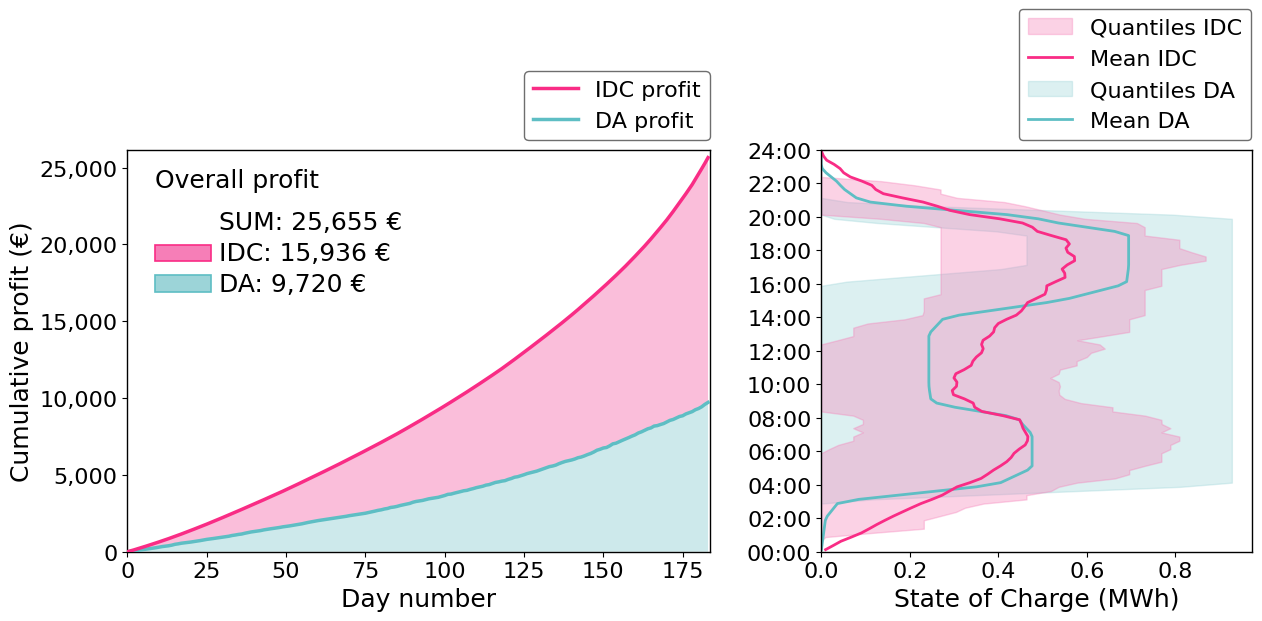

In [49]:
import matplotlib.pyplot as plt
from evaluation.coordinated_rl_test_plots import myopic_cumulative_profit_and_soc_figure

plot_name = "myopic_cumulative_profit_and_soc_figure"

fig_m, ax_cum_m, ax_soc_m, profit_tbl_m, mat_da_m, mat_all_m, s_da_m, s_all_m = (
    myopic_cumulative_profit_and_soc_figure(
        df_test["delivery_day"],
        e_max_mwh=1.0,
        soc0_mwh=0.0,
        q_low=SOC_Q_LOW,
        q_high=SOC_Q_HIGH,
    )
)
filepath = os.path.join(folder, f"{plot_name}_model_{SELECTED_MODEL}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

### Training vs validation profit (side by side)

**Left — TensorBoard (training):** mean **combined € profit** from `episode_profit/combined_eur` vs **environment timestep** (`output/coordinated_multi_market/tensorboard/<name>/`, see `evaluation.rl_model_registry`). **Raw** curve (faint) plus a **moving average** over the last `RL_TB_MOVING_AVG_WINDOW` samples (training only).

**Right — checkpoint sweep (validation):** `validation_precomputed/validation_summary.csv`: **x** = training **steps**, **y** = **`mean_profit`** (or **`profit`**) on the **validation holdout**. Checkpoints are shown as markers with a faint connecting line (**no** moving average on this panel).


**Horizontal guides (left):** **train-fit** days — **solid** lines: **Myopic multi-market**, **Single market (rolling intrinsic)**; **same dashed style**, **different colours**: **Daily max**, **Daily q90**, and **Best avg DA pattern** (`no_da` / `combo_id == 0` excluded; `evaluation.brute_force_summary_stats.best_mean_profit_da_pattern_over_days`).

**Horizontal guides (right):** **validation holdout** means; same line/colour rules. **Best pattern** line is the **same** train-winning pattern evaluated on validation days (`mean_profit_for_pattern_over_days`).

**Colours:** Seaborn **colorblind** hex values in the code cell; coordinated RL curves use the first swatch.

**Typography:** **x**/**y** axis **titles** and legend at 18 pt; **y** tick labels at 16 pt; **x** tick labels only at 12 pt.

**Legend:** one shared entry list under both panels (taken from the training axis); the validation **checkpoint** curve is not listed separately because it has no counterpart on the left.


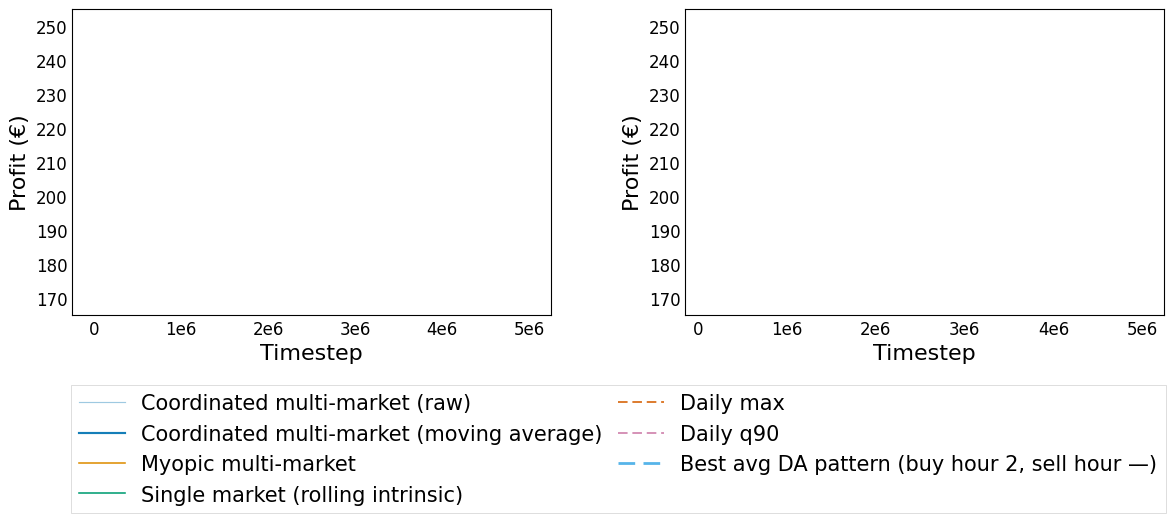

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter, MultipleLocator

from evaluation.brute_force_summary_stats import (
    best_mean_profit_da_pattern_over_days,
    mean_profit_for_pattern_over_days,
)
from evaluation.rl_model_registry import rl_tensorboard_run_dir, rl_validation_summary_csv_path
from evaluation.tensorboard_rl_curves import EPISODE_PROFIT_COMBINED_TAG, load_tensorboard_scalar
from evaluation.training_period_baselines import (
    build_training_period_baselines_df,
    mean_reference_values_train_fit,
    mean_reference_values_validation_holdout,
)

plot_name = "training_vs_validation_profit_figure"

# y-axis label, legend, and x-axis *title*; y tick labels
LABEL_FONTSIZE = 16
TICK_FONTSIZE_Y = 12
# x-axis *tick* labels only (x-axis title stays LABEL_FONTSIZE)
X_TICK_FONTSIZE = 12

# Seaborn default "colorblind" palette (Wong-style) — same hex as seaborn.color_palette("colorblind")
_SEABORN_COLORBLIND = (
    "#0173B2",
    "#DE8F05",
    "#029E73",
    "#D55E00",
    "#CC79A7",
    "#F0E442",
    "#56B4E9",
    "#009E73",
)
_RL_BLUE = _SEABORN_COLORBLIND[0]

# Rolling mean over this many TensorBoard samples (training panel only)
RL_TB_MOVING_AVG_WINDOW = 200

# Optional: force the same y-axis range for BOTH panels.
# Set either bound to None to auto-scale.
Y_LIM_MIN = 165
Y_LIM_MAX = 255

# Still returned by baselines helpers; omit from the figure (legend + lines)
SKIP_REF_KEYS = frozenset({"mean_brute_q075_eur"})

# Solid: myopic, single-market RI. Shared non-solid style: daily max, daily q90, best DA pattern
_SOLID_REF_KEYS = frozenset({"mean_myopic_eur", "mean_single_market_ri_eur"})
_LS_MAX_Q90_PATTERN = (0, (6, 3))

_COLOR_BEST_PATTERN = _SEABORN_COLORBLIND[6]  # distinct from max / q90 swatches below

tb_dir = rl_tensorboard_run_dir(SELECTED_MODEL)
df_tb_train = load_tensorboard_scalar(tb_dir, EPISODE_PROFIT_COMBINED_TAG)

df_train_period = build_training_period_baselines_df(SELECTED_MODEL)
refs_train = mean_reference_values_train_fit(df_train_period)
refs_val = mean_reference_values_validation_holdout(df_train_period)

train_fit_days = df_train_period.loc[~df_train_period["is_validation_day"], "delivery_day"]
val_days = df_train_period.loc[df_train_period["is_validation_day"], "delivery_day"]

best_pattern_mean, best_pattern_info = best_mean_profit_da_pattern_over_days(train_fit_days)
pattern_mean_on_val = (
    mean_profit_for_pattern_over_days(best_pattern_info, val_days)
    if best_pattern_info and "buy_hour" in best_pattern_info
    else None
)

sum_path = rl_validation_summary_csv_path(SELECTED_MODEL)
df_val_sum = pd.read_csv(sum_path)
if "steps" not in df_val_sum.columns:
    raise ValueError(f"{sum_path}: expected column 'steps'")
y_col = "mean_profit" if "mean_profit" in df_val_sum.columns else "profit"
if y_col not in df_val_sum.columns:
    raise ValueError(f"{sum_path}: need 'mean_profit' or 'profit'")
df_val_sum = df_val_sum.sort_values("steps").reset_index(drop=True)
steps_v = df_val_sum["steps"].to_numpy(dtype=float)
y_v = df_val_sum[y_col].to_numpy(dtype=float)


def _hour_label(x) -> str:
    if not pd.notna(x):
        return "—"
    xf = float(x)
    if abs(xf - round(xf)) < 1e-6:
        return str(int(round(xf)))
    return f"{xf:g}"


def _best_pattern_legend_label(info: dict) -> str:
    """DA hours use CSV convention 1…24."""
    bh = _hour_label(info.get("buy_hour")) if info else "—"
    sh = _hour_label(info.get("sell_hour")) if info else "—"
    return f"Best avg DA pattern (buy hour {bh}, sell hour {sh})"


_ref_labels = {
    "mean_myopic_eur": "Myopic multi-market",
    "mean_single_market_ri_eur": "Single market (rolling intrinsic)",
    "mean_theoretical_max_eur": "Daily max",
    "mean_brute_q090_eur": "Daily q90",
}


def _ref_legend_label(key: str) -> str:
    return _ref_labels.get(key, key)


_ref_colors = {
    "mean_myopic_eur": _SEABORN_COLORBLIND[1],
    "mean_single_market_ri_eur": _SEABORN_COLORBLIND[2],
    "mean_theoretical_max_eur": _SEABORN_COLORBLIND[3],
    "mean_brute_q090_eur": _SEABORN_COLORBLIND[4],
}


def _format_timestep_e6(x, _pos):
    if x == 0:
        return "0"
    return f"{x / 1e6:g}e6"


_ma_min_tb = max(3, RL_TB_MOVING_AVG_WINDOW // 4)
tb_ma = (
    df_tb_train["value"]
    .rolling(window=RL_TB_MOVING_AVG_WINDOW, min_periods=_ma_min_tb)
    .mean()
)

fig, (ax_tb, ax_v) = plt.subplots(1, 2, figsize=(12.0, 4.25), sharey=False)

ax_tb.plot(
    df_tb_train["step"],
    df_tb_train["value"],
    color=_RL_BLUE,
    lw=0.85,
    alpha=0.38,
    zorder=1,
    label="Coordinated multi-market (raw)",
)
ax_tb.plot(
    df_tb_train["step"],
    tb_ma,
    color=_RL_BLUE,
    lw=1.55,
    alpha=0.92,
    zorder=2,
    linestyle="-",
    label="Coordinated multi-market (moving average)",
)
for key, y in refs_train.items():
    if key in SKIP_REF_KEYS:
        continue
    ls = "-" if key in _SOLID_REF_KEYS else _LS_MAX_Q90_PATTERN
    ax_tb.axhline(
        y,
        color=_ref_colors.get(key, "#333333"),
        ls=ls,
        lw=1.15,
        zorder=3,
        label=_ref_legend_label(key),
    )
if best_pattern_mean is not None:
    ax_tb.axhline(
        best_pattern_mean,
        color=_COLOR_BEST_PATTERN,
        ls=_LS_MAX_Q90_PATTERN,
        lw=2.0,
        zorder=3,
        label=_best_pattern_legend_label(best_pattern_info),
    )
ax_tb.set_ylabel("Profit (€)", fontsize=LABEL_FONTSIZE)
ax_tb.set_xlabel("Timestep", fontsize=LABEL_FONTSIZE)
ax_tb.xaxis.set_major_locator(MultipleLocator(1e6))
ax_tb.xaxis.set_major_formatter(FuncFormatter(_format_timestep_e6))

ax_v.plot(
    steps_v,
    y_v,
    "o",
    ms=3.2,
    alpha=0.45,
    color=_RL_BLUE,
    zorder=1,
)
ax_v.plot(
    steps_v,
    y_v,
    "-",
    lw=0.75,
    alpha=0.35,
    color=_RL_BLUE,
    zorder=1,
    label="Coordinated multi-market (checkpoints)",
)
for key, y in refs_val.items():
    if key in SKIP_REF_KEYS:
        continue
    ls = "-" if key in _SOLID_REF_KEYS else _LS_MAX_Q90_PATTERN
    ax_v.axhline(
        y,
        color=_ref_colors.get(key, "#333333"),
        ls=ls,
        lw=1.15,
        zorder=3,
        label=_ref_legend_label(key),
    )
if pattern_mean_on_val is not None:
    ax_v.axhline(
        pattern_mean_on_val,
        color=_COLOR_BEST_PATTERN,
        ls=_LS_MAX_Q90_PATTERN,
        lw=2.0,
        zorder=3,
        label=_best_pattern_legend_label(best_pattern_info),
    )
ax_v.set_ylabel("Profit (€)", fontsize=LABEL_FONTSIZE)
ax_v.set_xlabel("Timestep", fontsize=LABEL_FONTSIZE)
ax_v.xaxis.set_major_locator(MultipleLocator(1e6))
ax_v.xaxis.set_major_formatter(FuncFormatter(_format_timestep_e6))

# One legend for the whole figure (left panel defines entries; right shares the same baselines / styles).
handles_leg, labels_leg = ax_tb.get_legend_handles_labels()
_LEGEND_FONTSIZE = max(8, LABEL_FONTSIZE -1)

# One compact boxed legend centered under both panels, horizontally aligned
# with the subplot area (left/right match fig.subplots_adjust()).
leg = fig.legend(
    handles_leg,
    labels_leg,
    loc="lower left",
    bbox_to_anchor=(0.07, -0.25, 0.93, 0.5),  # (left, bottom, width, height) in figure coords
    mode="expand",
    ncol=2,
    fontsize=_LEGEND_FONTSIZE,
    frameon=True,
    framealpha=0.7,
    facecolor="#FFFFFF",
    edgecolor="#C8C8C8",
    fancybox=False,
    columnspacing=1.0,
    handlelength=2.2,
)
leg.get_frame().set_linewidth(0.6)

# Apply manual y-limits (same for both panels) if requested.
if Y_LIM_MIN is not None or Y_LIM_MAX is not None:
    for _ax in (ax_tb, ax_v):
        _ax.set_ylim(bottom=Y_LIM_MIN, top=Y_LIM_MAX)

for ax in (ax_tb, ax_v):
    ax.tick_params(
        axis="x",
        which="both",
        length=0,
        labelsize=X_TICK_FONTSIZE,
    )
    ax.tick_params(
        axis="y",
        which="both",
        length=0,
        labelsize=TICK_FONTSIZE_Y,
    )
    ax.grid(False)

# Leave space for the boxed legend under the panels.
fig.subplots_adjust(bottom=0.24, top=0.96, left=0.08, right=0.99, wspace=0.28)
filepath = os.path.join(folder, f"{plot_name}_model_{SELECTED_MODEL}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()


**Training-period baselines table** (from the cell above): `df_train_period` = all days in the registry training window present in myopic `profit.csv`, merged with single-market RI + brute-force stats. Rows with `is_validation_day` are the random holdout; train-fit means use `~is_validation_day` (see `split_training_baselines_train_vs_validation` if you want two frames).


In [51]:
pd.Series(
    {
        "days_in_window": len(df_train_period),
        "train_fit_rows": int((~df_train_period["is_validation_day"]).sum()),
        "validation_holdout_rows": int(df_train_period["is_validation_day"].sum()),
    }
)


days_in_window             821
train_fit_rows             731
validation_holdout_rows     90
dtype: int64

In [52]:
df_train_period.describe()


,profit_myopic,profit_single_market_ri,theoretical_max_profit,brute_median_profit,brute_q075_profit,brute_q090_profit,theoretical_max_da_profit,brute_median_da_profit,brute_q075_da_profit,brute_q090_da_profit,theoretical_max_idc_profit,brute_median_idc_profit,brute_q075_idc_profit,brute_q090_idc_profit
count,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000
mean,72.248232,83.935564,110.033516,78.276773,87.130072,94.210857,-5.166662,-2.440770,-0.472758,-0.367354,115.200178,80.717543,87.602830,94.578211
std,48.278408,53.894100,72.614884,49.152668,53.988020,57.474740,20.613307,15.671943,18.021716,16.559227,75.702028,49.373350,56.336089,58.147885
min,5.288567,17.538780,31.143158,18.244037,21.167405,24.127095,-103.881400,-66.070000,-122.445200,-68.850000,31.143158,16.828390,24.244962,24.633562
25%,43.269497,53.633215,71.683721,48.688401,56.256601,60.840226,-12.531800,-8.824200,-6.913800,-7.033200,74.482327,50.507136,54.935924,59.614619
50%,62.289791,71.979785,93.199010,66.231504,74.383779,80.641735,-3.155400,-2.454200,0.023000,0.000000,98.543429,68.326681,75.799002,82.206161
75%,87.474255,100.465209,126.232376,92.249760,102.199859,109.716549,4.928400,5.684000,8.767200,7.256600,131.586005,95.489151,103.387400,110.681932
max,725.128381,905.855102,1156.318012,769.326096,875.005705,919.802217,94.944200,89.626200,108.526600,88.951600,1260.199412,793.607496,997.450905,933.021617


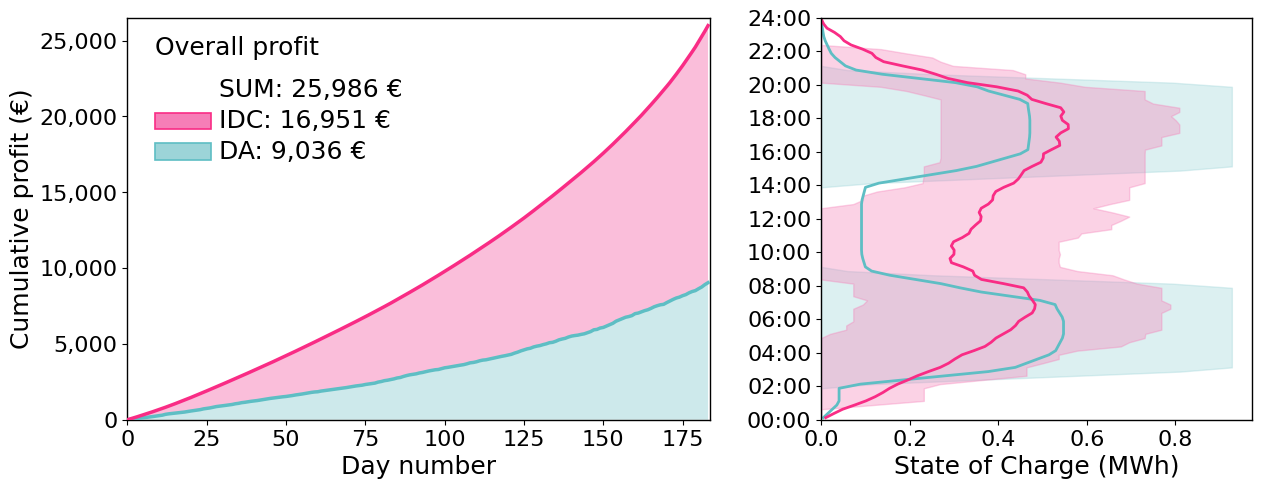

In [53]:
import matplotlib.pyplot as plt
from evaluation.coordinated_rl_test_plots import coordinated_rl_cumulative_profit_and_soc_figure

plot_name = "coordinated_rl_cumulative_profit_and_soc_figure_no_top_legends"

fig_c2, ax_cum_c2, ax_soc_c2, profit_tbl_c2, mat_da_c2, mat_all_c2, s_da_c2, s_all_c2 = (
    coordinated_rl_cumulative_profit_and_soc_figure(
        SELECTED_MODEL,
        df_test["delivery_day"],
        e_max_mwh=1.0,
        soc0_mwh=0.0,
        q_low=SOC_Q_LOW,
        q_high=SOC_Q_HIGH,
        show_top_legends=False,
        reserve_top_legend_space=True,
    )
)
filepath = os.path.join(folder, f"{plot_name}_model_{SELECTED_MODEL}.png")
plt.savefig(filepath, dpi=300, bbox_inches="tight")
plt.show()

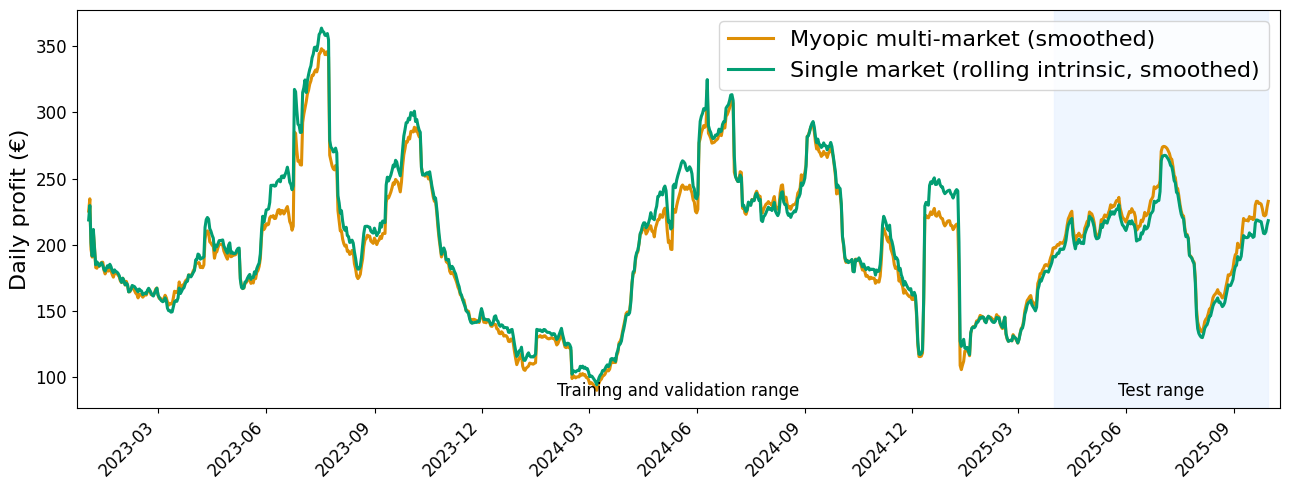

In [54]:
# Smoothed daily-profit comparison over a configurable calendar window
# (uses full myopic + single-market RI history from profit.csv files)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from evaluation.merge_test_profits import load_profit_csv
from evaluation.rl_model_registry import baseline_paths_bs15

plot_name = "myopic_and_single_market_ri_daily_profit_comparison"

dataset = 2 # set 1 or 2

if dataset == 1:
    # --- user settings ---
    START_DATE = "2019-01-01"
    END_DATE = "2021-09-30"
    SMOOTHING_WINDOW_DAYS = 30  # moving-average window in days
    SMOOTHING_MIN_PERIODS = 1   # set to SMOOTHING_WINDOW_DAYS for strict full-window MA

    # Range shading configuration
    TRAIN_RANGE_START = "2019-01-01"
    TRAIN_RANGE_END = "2021-03-30"
    TEST_RANGE_START = "2021-04-01"
    TEST_RANGE_END = "2021-09-30"
else:
    # --- user settings for dataset 2 ---
    START_DATE = "2023-01-01"
    END_DATE = "2025-09-30"
    SMOOTHING_WINDOW_DAYS = 30
    SMOOTHING_MIN_PERIODS = 1

    TRAIN_RANGE_START = "2023-01-01"
    TRAIN_RANGE_END = "2025-09-30"
    TEST_RANGE_START = "2025-04-01"
    TEST_RANGE_END = "2025-09-30"

TRAIN_BAND_COLOR = "#FFFFFF"
TEST_BAND_COLOR = "#EAF3FF"
BAND_ALPHA = 0.75


# Seaborn default "colorblind" palette (Wong-style) — same hex as seaborn.color_palette("colorblind")
_SEABORN_COLORBLIND = (
    "#0173B2",
    "#DE8F05",
    "#029E73",
    "#D55E00",
    "#CC79A7",
    "#F0E442",
    "#56B4E9",
    "#009E73",
)

# Optional: keep bs-folder explicit if needed elsewhere in notebook.
_BS_FOLDER = "bs15cr1rto0.86mc365mt10"

# Resolve baseline files and load full daily series.
_base_paths = baseline_paths_bs15(bs_folder=_BS_FOLDER)
_myopic = load_profit_csv(_base_paths["myopic"]).rename(columns={"profit": "profit_myopic"})
_single = load_profit_csv(_base_paths["single_file"]).rename(
    columns={"profit": "profit_single_market_ri"}
)

# Outer merge keeps all available days across both baselines.
_df = (
    _myopic[["delivery_day", "profit_myopic"]]
    .merge(
        _single[["delivery_day", "profit_single_market_ri"]],
        on="delivery_day",
        how="outer",
    )
    .sort_values("delivery_day")
    .reset_index(drop=True)
)

# Filter date range (Berlin calendar days).
_start = pd.Timestamp(START_DATE, tz="Europe/Berlin").normalize()
_end = pd.Timestamp(END_DATE, tz="Europe/Berlin").normalize()
_df = _df.loc[(_df["delivery_day"] >= _start) & (_df["delivery_day"] <= _end)].copy()

# Smoothed lines (rolling moving average).
_df["myopic_smooth"] = _df["profit_myopic"].rolling(
    window=SMOOTHING_WINDOW_DAYS,
    min_periods=SMOOTHING_MIN_PERIODS,
).mean()
_df["single_ri_smooth"] = _df["profit_single_market_ri"].rolling(
    window=SMOOTHING_WINDOW_DAYS,
    min_periods=SMOOTHING_MIN_PERIODS,
).mean()

# Plot
fig, ax = plt.subplots(figsize=(13.0, 5.0))

# Optional background regime bands.
_t0 = pd.Timestamp(TRAIN_RANGE_START, tz="Europe/Berlin").normalize()
_t1 = pd.Timestamp(TRAIN_RANGE_END, tz="Europe/Berlin").normalize()
_s0 = pd.Timestamp(TEST_RANGE_START, tz="Europe/Berlin").normalize()
_s1 = pd.Timestamp(TEST_RANGE_END, tz="Europe/Berlin").normalize()

if _t0 <= _t1:
    ax.axvspan(_t0, _t1, color=TRAIN_BAND_COLOR, alpha=BAND_ALPHA, zorder=0)
if _s0 <= _s1:
    ax.axvspan(_s0, _s1, color=TEST_BAND_COLOR, alpha=BAND_ALPHA, zorder=0)

ax.plot(
    _df["delivery_day"],
    _df["myopic_smooth"],
    lw=2.2,
    color="#DE8F05",
    label="Myopic multi-market (smoothed)",
    zorder=3,
)
ax.plot(
    _df["delivery_day"],
    _df["single_ri_smooth"],
    lw=2.2,
    color="#029E73",
    label="Single market (rolling intrinsic, smoothed)",
    zorder=3,
)

ax.set_xlabel("", fontsize=16)
ax.set_ylabel("Daily profit (€)", fontsize=16)
ax.grid(False)
ax.legend(frameon=True, fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=12)

# Keep a small left/right margin while staying tighter than Matplotlib defaults.
X_PAD_DAYS = 10
ax.set_xlim(_start - pd.Timedelta(days=X_PAD_DAYS), _end + pd.Timedelta(days=X_PAD_DAYS))
ax.margins(x=0)

# Month ticks on x-axis.
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# In-chart range labels near the x-axis.
_y0, _y1 = ax.get_ylim()
_y_text = _y0 + 0.02 * (_y1 - _y0)
if _t0 <= _t1:
    _tx = _t0 + (_t1 - _t0) / 2
    ax.text(
        _tx,
        _y_text,
        "Training and validation range",
        ha="center",
        va="bottom",
        fontsize=12,
    )
if _s0 <= _s1:
    _sx = _s0 + (_s1 - _s0) / 2
    ax.text(_sx, _y_text, "Test range", ha="center", va="bottom", fontsize=12)

fig.tight_layout()

filepath = os.path.join(folder, f"{plot_name}_dataset_{dataset}.png")
plt.savefig(filepath, dpi=300, bbox_inches="tight")

plt.show()


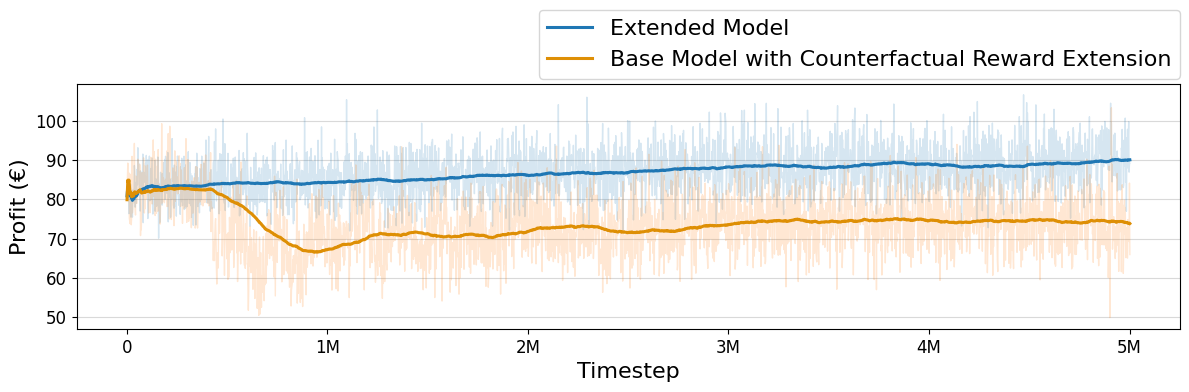

In [55]:
# TensorBoard comparison: episode_profit/combined_eur for two selectable models

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter, MultipleLocator

from evaluation.rl_model_registry import rl_tensorboard_run_dir
from evaluation.tensorboard_rl_curves import (
    EPISODE_PROFIT_COMBINED_TAG,
    load_tensorboard_scalar,
)

plot_name = "tensorboard_combined_profit"
# --- user settings ---
MODEL_A = 1
MODEL_B = 12
TB_MOVING_AVG_WINDOW = 200  # set to 1 for no smoothing
SHOW_RAW = True

# Match style of the existing TensorBoard plot cell
LABEL_FONTSIZE = 16
X_TICK_FONTSIZE = 12
Y_TICK_FONTSIZE = 12


def _format_timestep_e6(x: float, pos: int) -> str:
    if abs(x) < 1e-9:
        return "0"
    return f"{x / 1e6:.0f}M"


def _load_tb_curve(model_id: int | str) -> pd.DataFrame:
    tb_dir = rl_tensorboard_run_dir(model_id)
    df = load_tensorboard_scalar(tb_dir, EPISODE_PROFIT_COMBINED_TAG).copy()
    df = df.sort_values("step").reset_index(drop=True)
    df["value_smooth"] = (
        pd.to_numeric(df["value"], errors="coerce")
        .rolling(TB_MOVING_AVG_WINDOW, min_periods=1)
        .mean()
    )
    return df


df_a = _load_tb_curve(MODEL_A)
df_b = _load_tb_curve(MODEL_B)

fig, ax = plt.subplots(figsize=(12.0, 4.25))

if SHOW_RAW:
    ax.plot(df_a["step"], df_a["value"], alpha=0.18, lw=1.0)
    ax.plot(df_b["step"], df_b["value"], alpha=0.18, lw=1.0)

ax.plot(
    df_a["step"],
    df_a["value_smooth"],
    lw=2.2,
    color="#1f77b4",
    label=f"Extended Model",
)
ax.plot(
    df_b["step"],
    df_b["value_smooth"],
    lw=2.2,
    color="#DE8F05",
    label=f"Base Model with Counterfactual Reward Extension", 
)

# No title/caption, as requested.
ax.set_xlabel("Timestep", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Profit (€)", fontsize=LABEL_FONTSIZE)
ax.xaxis.set_major_locator(MultipleLocator(1e6))
ax.xaxis.set_major_formatter(FuncFormatter(_format_timestep_e6))
ax.tick_params(axis="x", which="major", labelsize=X_TICK_FONTSIZE)
ax.tick_params(axis="y", which="major", labelsize=Y_TICK_FONTSIZE)
ax.grid(axis="y", which="major", color="#D0D0D0", linestyle="-", linewidth=0.8, alpha=0.8)
ax.grid(axis="x", which="major", visible=False)

# Legend above the axes, right-aligned with plot area
ax.legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.02),
    borderaxespad=0.0,
    frameon=True,
    fontsize=LABEL_FONTSIZE,
)

fig.tight_layout(rect=(0, 0, 1, 0.95))

filepath = os.path.join(folder, f"{plot_name}_dataset_model_{MODEL_A}_model_{MODEL_B}.png")
plt.savefig(filepath, dpi=300, bbox_inches="tight")


plt.show()


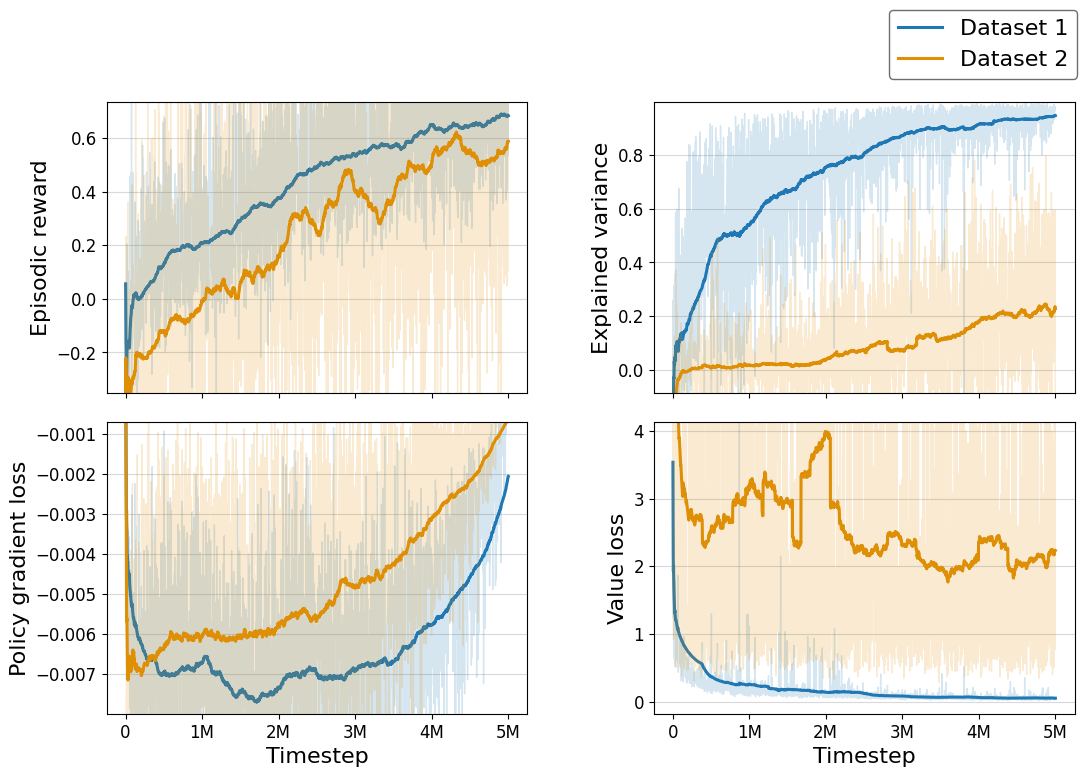

In [56]:
# TensorBoard: vier Metriken in einem 2×2-Subplot-Raster (quadratisch), eine gemeinsame Legende
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MultipleLocator

from evaluation.rl_model_registry import rl_tensorboard_run_dir
from evaluation.tensorboard_rl_curves import load_tensorboard_scalar

plot_name_grid = "tensorboard_metrics_grid_2x2"
# --- user settings ---
TB_COMPARE_MODEL_IDS = [1, 3]  # Reihenfolge = Legende; Farben siehe TB_MODEL_COLORS / Fallback
TB_MOVING_AVG_WINDOW = 200
SHOW_RAW = True

# Y-Achse: Ausreißer großzügig aus der Skala nehmen (Perzentile über alle Modelle pro Metrik)
TB_Y_AXIS_PERCENTILES = (1.0, 98.5)  # enger z.B. (5, 95), weiter z.B. (0.5, 99.5)
TB_Y_AXIS_PAD_FRACTION = 0.06
TB_Y_LIM_FROM_SMOOTH_ONLY = True  # True: ylim nur aus MA — Rohkurve kann am Rand abgeschnitten sein

# Explizite Farben pro Modell-ID (über alle Metrik-Plots identisch). Fehlende IDs: Fallback-Palette der Reihe nach.
TB_MODEL_COLORS = {
    1: "#1f77b4",
    3: "#DE8F05",
    12: "#2ca02c",
}

# Legenden-Texte (hier RL-Modelle 1 / 3 als "Dataset 1" / "Dataset 2" bezeichnet)
TB_MODEL_LEGEND_LABELS = {
    1: "Dataset 1",
    3: "Dataset 2",
}

# (TensorBoard-Scalar-Tag, Y-Achsen-Label, Kurzer Name für PNG-Dateiname)
TB_METRICS = [
    ("episode_reward/combined_sum", "Episodic reward", "episode_reward_combined_sum"),
    ("train/explained_variance", "Explained variance", "train_explained_variance"),
    ("train/policy_gradient_loss", "Policy gradient loss", "train_policy_gradient_loss"),
    ("train/value_loss", "Value loss", "train_value_loss"),
]

LABEL_FONTSIZE = 16
X_TICK_FONTSIZE = 12
Y_TICK_FONTSIZE = 12


def _robust_ylim_from_series(
    arrays: list[np.ndarray],
    low_pct: float,
    high_pct: float,
    pad_frac: float,
) -> tuple[float, float] | None:
    parts: list[np.ndarray] = []
    for a in arrays:
        a = np.asarray(a, dtype=float).ravel()
        a = a[np.isfinite(a)]
        if a.size:
            parts.append(a)
    if not parts:
        return None
    vals = np.concatenate(parts)
    lo, hi = np.percentile(vals, [low_pct, high_pct])
    span = float(hi - lo)
    if not np.isfinite(span):
        return None
    if span <= 0:
        m = float(np.nanmean(vals))
        span = max(abs(m), 1.0) * 0.05
        lo, hi = m - span, m + span
    pad = span * pad_frac
    return float(lo - pad), float(hi + pad)


def _format_timestep_e6(x: float, pos: int) -> str:
    if abs(x) < 1e-9:
        return "0"
    return f"{x / 1e6:.0f}M"


def _assign_model_colors(model_ids: list[int]) -> dict[int, str]:
    base = ["#1f77b4", "#DE8F05", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    out: dict[int, str] = {}
    bi = 0
    for mid in model_ids:
        if mid in TB_MODEL_COLORS:
            out[mid] = TB_MODEL_COLORS[mid]
        else:
            out[mid] = base[bi % len(base)]
            bi += 1
    return out


def _load_tb_series(model_id: int, tag: str) -> pd.DataFrame | None:
    try:
        tb_dir = rl_tensorboard_run_dir(model_id)
        df = load_tensorboard_scalar(tb_dir, tag).copy()
    except (FileNotFoundError, KeyError) as e:
        print(f"[TensorBoard] model {model_id} tag {tag!r}: {e}")
        return None
    df = df.sort_values("step").reset_index(drop=True)
    df["value_smooth"] = (
        pd.to_numeric(df["value"], errors="coerce")
        .rolling(TB_MOVING_AVG_WINDOW, min_periods=1)
        .mean()
    )
    return df


_model_ids = [int(m) for m in TB_COMPARE_MODEL_IDS]
_colors = _assign_model_colors(_model_ids)
_ids_suffix = "_".join(f"model_{mid}" for mid in _model_ids)

if len(TB_METRICS) != 4:
    raise ValueError(
        f"Dieses Raster erwartet genau 4 Metriken (2×2), aktuell len(TB_METRICS)={len(TB_METRICS)}"
    )

_legend_handles = [
    Line2D([0], [0], color=_colors[mid], lw=2.2, label=TB_MODEL_LEGEND_LABELS.get(mid, f"Model {mid}"))
    for mid in _model_ids
]

# Breiter als hoch (flachere Subplots); Abstand Mitte über wspace/hspace
TB_GRID_FIGSIZE = (11.0, 7.2)
TB_GRID_WSPACE = 0.3
TB_GRID_HSPACE = 0.1
TB_LEGEND_FONTSIZE = 16

fig, axes = plt.subplots(2, 2, figsize=TB_GRID_FIGSIZE, sharex=True)

for ax, (tag, y_label, slug) in zip(axes.ravel(), TB_METRICS):
    loaded: list[tuple[int, pd.DataFrame]] = []
    for model_id in _model_ids:
        df = _load_tb_series(model_id, tag)
        if df is None or df.empty:
            continue
        loaded.append((model_id, df))

    y_for_ylim: list[np.ndarray] = []
    for _, df in loaded:
        y_for_ylim.append(df["value_smooth"].to_numpy())
        if SHOW_RAW and not TB_Y_LIM_FROM_SMOOTH_ONLY:
            y_for_ylim.append(pd.to_numeric(df["value"], errors="coerce").to_numpy())

    ylim = _robust_ylim_from_series(
        y_for_ylim,
        TB_Y_AXIS_PERCENTILES[0],
        TB_Y_AXIS_PERCENTILES[1],
        TB_Y_AXIS_PAD_FRACTION,
    )

    for model_id, df in loaded:
        c = _colors[model_id]
        if SHOW_RAW:
            ax.plot(
                df["step"],
                df["value"],
                color=c,
                alpha=0.18,
                lw=1.0,
                clip_on=True,
            )
        ax.plot(
            df["step"],
            df["value_smooth"],
            lw=2.2,
            color=c,
            clip_on=True,
        )
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.set_ylabel(y_label, fontsize=LABEL_FONTSIZE)
    ax.xaxis.set_major_locator(MultipleLocator(1e6))
    ax.xaxis.set_major_formatter(FuncFormatter(_format_timestep_e6))
    ax.tick_params(axis="x", which="major", labelsize=X_TICK_FONTSIZE)
    ax.tick_params(axis="y", which="major", labelsize=Y_TICK_FONTSIZE)
    ax.grid(axis="y", which="major", color="#D0D0D0", linestyle="-", linewidth=0.8, alpha=0.8)
    ax.grid(axis="x", which="major", visible=False)

for ax in axes[0, :]:
    ax.set_xlabel("")
for ax in axes[1, :]:
    ax.set_xlabel("Timestep", fontsize=LABEL_FONTSIZE)

# Kompakte Legende oben rechts (wie myopic_cumulative_profit_and_soc_figure / ax_cum.legend)
axes[0, 1].legend(
    handles=_legend_handles,
    loc="lower right",
    bbox_to_anchor=(1.02, 1.06),
    borderaxespad=0.25,
    fontsize=TB_LEGEND_FONTSIZE,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="#666666",
    fancybox=True,
)

fig.subplots_adjust(
    left=0.09,
    right=0.97,
    bottom=0.11,
    top=0.96,
    wspace=TB_GRID_WSPACE,
    hspace=TB_GRID_HSPACE,
)
filepath = os.path.join(folder, f"{plot_name_grid}_{_ids_suffix}.png")
plt.savefig(filepath, dpi=300, bbox_inches="tight")
plt.show()


In [57]:
# Analyse: durchschnittlicher Daily Profit mit vs. ohne offene DA-Position (pro Modell)

from pathlib import Path
import pandas as pd

from evaluation.rl_model_registry import rl_rolling_intrinsic_profit_path

# Modellliste hier anpassen (Variablenname exakt: MODEL_IDS).
MODEL_IDS = [1, 3, 5, 11, 17]
#MODEL_IDS = MODEL_IDS if "MODEL_IDS" in globals() else [1, 3,5,11,17]
BS_FOLDER = BS_FOLDER if "BS_FOLDER" in globals() else "bs15cr1rto0.86mc365mt10"


def _delivery_day_berlin(day_series: pd.Series) -> pd.Series:
    ts = pd.to_datetime(day_series, utc=True, errors="coerce")
    return ts.dt.tz_convert("Europe/Berlin").dt.normalize()


def _open_da_flag_per_day(trades_dir: Path, delivery_day: pd.Timestamp) -> bool | None:
    """
    True  -> offene DA-Position (Buy vorhanden, Sell fehlt am DA-Zeitpunkt)
    False -> keine offene DA-Position
    None  -> nicht bewertbar (z.B. fehlende Datei/Spalten)
    """
    dd = pd.Timestamp(delivery_day).tz_convert("Europe/Berlin").normalize()
    fp = trades_dir / f"trades_{dd.date().isoformat()}.csv"
    if not fp.is_file():
        return None

    t = pd.read_csv(fp)
    if t.empty or "execution_time" not in t.columns or "side" not in t.columns:
        return None

    ex = pd.to_datetime(t["execution_time"], utc=True, errors="coerce").dt.tz_convert("Europe/Berlin")
    sides = t["side"].astype(str).str.lower().str.strip()

    da_time = (dd - pd.Timedelta(days=1)).replace(hour=13, minute=0, second=0)
    da_mask = ex == da_time
    if not da_mask.any():
        return False

    n_buy = int((sides[da_mask] == "buy").sum())
    n_sell = int((sides[da_mask] == "sell").sum())
    return bool(n_buy > 0 and n_sell == 0)


rows = []
for model_id in MODEL_IDS:
    profit_csv = rl_rolling_intrinsic_profit_path(model_id, bs_folder=BS_FOLDER)
    if not Path(profit_csv).is_file():
        rows.append(
            {
                "model": str(model_id),
                "n_days_total": 0,
                "n_days_open_da": 0,
                "share_day_open_da": float("nan"),
                "mean_profit_open_da": float("nan"),
                "mean_profit_not_open_da": float("nan"),
            }
        )
        continue

    trades_dir = Path(profit_csv).parent / "trades"
    dfp = pd.read_csv(profit_csv)
    if "day" not in dfp.columns or "profit" not in dfp.columns:
        raise ValueError(f"{profit_csv}: expected columns 'day' and 'profit'")

    dfp = dfp.copy()
    dfp["delivery_day"] = _delivery_day_berlin(dfp["day"])
    dfp["profit"] = pd.to_numeric(dfp["profit"], errors="coerce")
    dfp = dfp.loc[dfp["delivery_day"].notna() & dfp["profit"].notna()].copy()

    flags = []
    for dd in dfp["delivery_day"]:
        flags.append(_open_da_flag_per_day(trades_dir, dd))
    dfp["open_da"] = flags

    rated = dfp.loc[dfp["open_da"].notna()].copy()
    open_days = rated.loc[rated["open_da"] == True]
    closed_days = rated.loc[rated["open_da"] == False]

    mean_open = float(open_days["profit"].mean()) if len(open_days) > 0 else float("nan")
    mean_closed = float(closed_days["profit"].mean()) if len(closed_days) > 0 else float("nan")

    rows.append(
        {
            "model": str(model_id),
            "n_days_total": int(len(dfp)),
            "n_days_open_da": int(len(open_days)),
            "share_day_open_da": (len(open_days) / len(dfp)) if len(dfp) > 0 else float("nan"),
            "mean_profit_open_da": mean_open,
            "mean_profit_not_open_da": mean_closed,
        }
    )


df_open_da_profit_split = pd.DataFrame(rows).sort_values("model", key=lambda s: s.astype(int))
df_open_da_profit_split


KeyboardInterrupt: 

In [ ]:
# RL vs Brute-Force: Quantilrang des Tagesprofits an Tagen mit offener DA-Position
#
# Idee: Wie ``df_open_da_profit_split``: alle Kalendertage aus dem jeweiligen Modell-``profit.csv``,
# an denen eine offene DA-Position erkannt wird. Optional nur Tage aus ``df_test`` (siehe Schalter).
# Pro solchem Tag: RL-Tagesprofit vs. Verteilung der Szenario-``profit``-Werte in ``summary_*.csv``.

from pathlib import Path

import pandas as pd

from evaluation.brute_force_summary_stats import (
    profit_quantile_vs_summary_file,
    summary_csv_path,
)
from evaluation.rl_model_registry import rl_rolling_intrinsic_profit_path

# Modelle **in dieser Zelle** setzen (Name exakt: MODEL_IDS — Tippfehler ODEL_IDS greift nicht).
# Alternativ vorher die Zelle mit MODEL_IDS ausführen; dann kannst du die nächste Zeile nutzen:
# MODEL_IDS = MODEL_IDS  # bewusst aus der vorherigen Zelle übernehmen
MODEL_IDS = [1, 3, 5, 11, 17]
BS_FOLDER = globals().get("BS_FOLDER", "bs15cr1rto0.86mc365mt10")
print("Quantil-Analyse — MODEL_IDS:", MODEL_IDS)

# Referenzverteilung: alle Zeilen mit profit (Standard). True = no_da-Zeilen weglassen.
EXCLUDE_NO_DA_FROM_REFERENCE = False

# False = gleicher Tagesumfang wie ``df_open_da_profit_split`` (alle Tage im Modell-profit.csv).
# True = nur Tage, die in ``df_test`` vorkommen (Kalender des aktuell gebauten Test-Frames).
USE_DF_TEST_DAYS = False
_allowed = None
if USE_DF_TEST_DAYS:
    if "df_test" not in globals():
        raise ValueError("USE_DF_TEST_DAYS=True, aber df_test fehlt.")
    _allowed = set(
        pd.to_datetime(df_test["delivery_day"], errors="coerce")
        .dt.tz_convert("Europe/Berlin")
        .dt.normalize()
        .dropna()
    )


def _delivery_day_berlin(day_series: pd.Series) -> pd.Series:
    ts = pd.to_datetime(day_series, utc=True, errors="coerce")
    return ts.dt.tz_convert("Europe/Berlin").dt.normalize()


def _open_da_flag_per_day(trades_dir: Path, delivery_day: pd.Timestamp) -> bool | None:
    dd = pd.Timestamp(delivery_day).tz_convert("Europe/Berlin").normalize()
    fp = trades_dir / f"trades_{dd.date().isoformat()}.csv"
    if not fp.is_file():
        return None
    t = pd.read_csv(fp)
    if t.empty or "execution_time" not in t.columns or "side" not in t.columns:
        return None
    ex = pd.to_datetime(t["execution_time"], utc=True, errors="coerce").dt.tz_convert(
        "Europe/Berlin"
    )
    sides = t["side"].astype(str).str.lower().str.strip()
    da_time = (dd - pd.Timedelta(days=1)).replace(hour=13, minute=0, second=0)
    da_mask = ex == da_time
    if not da_mask.any():
        return False
    n_buy = int((sides[da_mask] == "buy").sum())
    n_sell = int((sides[da_mask] == "sell").sum())
    return bool(n_buy > 0 and n_sell == 0)


rows_detail: list[dict] = []
for model_id in MODEL_IDS:
    profit_csv = rl_rolling_intrinsic_profit_path(model_id, bs_folder=BS_FOLDER)
    if not Path(profit_csv).is_file():
        continue
    trades_dir = Path(profit_csv).parent / "trades"
    dfp = pd.read_csv(profit_csv)
    dfp["delivery_day"] = _delivery_day_berlin(dfp["day"])
    dfp["profit"] = pd.to_numeric(dfp["profit"], errors="coerce")
    # Mehrere Zeilen pro Tag? Dann Mittelwert (set_index würde sonst doppelte Indexe liefern).
    by_day = dfp.groupby("delivery_day", sort=False)["profit"].mean()

    for dd_ts in sorted(by_day.index.unique()):
        dd_ts = pd.Timestamp(dd_ts).tz_convert("Europe/Berlin").normalize()
        if _allowed is not None and dd_ts not in _allowed:
            continue
        flag = _open_da_flag_per_day(trades_dir, dd_ts)
        if flag is not True:
            continue

        rl_profit = float(by_day.loc[dd_ts])
        sp = summary_csv_path(dd_ts)
        q = profit_quantile_vs_summary_file(
            sp,
            rl_profit,
            exclude_no_da_rows=EXCLUDE_NO_DA_FROM_REFERENCE,
        )
        if sp.is_file():
            n_scen = int(pd.read_csv(sp)["profit"].notna().sum())
        else:
            n_scen = 0

        rows_detail.append(
            {
                "model": str(model_id),
                "delivery_day": dd_ts,
                "rl_daily_profit_eur": rl_profit,
                "n_summary_scenarios": n_scen,
                "profit_quantile_in_brute_distribution": q,
            }
        )

df_open_da_brute_quantile_detail = pd.DataFrame(rows_detail)

# Eine Zeile pro gewünschtem Modell (0 Tage = keine offene DA im Test für dieses Modell)
_agg = []
for m in sorted(MODEL_IDS, key=lambda x: int(str(x))):
    g = df_open_da_brute_quantile_detail[
        df_open_da_brute_quantile_detail["model"] == str(m)
    ]
    s = pd.to_numeric(g["profit_quantile_in_brute_distribution"], errors="coerce")
    _agg.append(
        {
            "model": str(m),
            "n_open_da_days": int(len(g)),
            "mean_profit_quantile_open_da_days": float(s.mean()) if len(g) else float("nan"),
            "median_profit_quantile_open_da_days": float(s.median()) if len(g) else float("nan"),
        }
    )

df_open_da_brute_quantile_agg = pd.DataFrame(_agg)

df_open_da_brute_quantile_agg


Quantil-Analyse — MODEL_IDS: [1, 3, 5, 11, 17]


,model,n_open_da_days,mean_profit_quantile_open_da_days,median_profit_quantile_open_da_days
0,1,0,NaN,NaN
1,3,14,0.494048,0.376667
2,5,48,0.627222,0.618333
3,11,1,0.865000,0.865000
4,17,0,NaN,NaN


### Brute-Force: Trades pro Tag und Profit pro Trade

Aus `coordinated_market_upper_bound_analysis/results_merged/trades/` (Ordner `YYYY-MM-DD/` mit `trades_combo_000.csv` … `299`) entsteht eine **lange Tabelle**: eine Zeile pro **Lieferkalendertag × Kombination** (300 Kombinationen), mit **`n_trades`**, **`daily_profit`** (Summe `profit` im File) und **`profit_per_trade`** = `daily_profit / n_trades`.

Die Tabelle wird als **Cache** unter `results_merged/brute_force_daily_combo_trade_stats.parquet` (oder `.csv` ohne PyArrow) abgelegt — Neuaufbau im nächsten Code mit `REBUILD_BRUTE_FORCE_TRADE_LONG = True` (kann je nach Datenmenge lange dauern).

**Monatliche** Aggregation (sinnvoll für mehrjährige Serien): **Balken** = mittlere Trade-Anzahl über alle Tag×Kombi-Zellen im Monat; **Linie** = Profit pro Trade (`use_pooled_line`: gesamter Monatsprofit ÷ gesamte Trades im Monat). Implementierung: `coordinated_market_upper_bound_analysis/brute_force_trades_daily_long_and_plots.py`.


/Users/timflaschel/Documents/GitHub/BessBidder1/coordinated_market_upper_bound_analysis/brute_force_trades_daily_long_and_plots.py:131: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  work["month"] = work["delivery_day"].dt.to_period("M").dt.to_timestamp(how="start")
/Users/timflaschel/Documents/GitHub/BessBidder1/coordinated_market_upper_bound_analysis/brute_force_trades_daily_long_and_plots.py:151: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = work.groupby("month", sort=True).apply(agg_month).reset_index()
/Users/timflaschel/Documents/GitHub/BessBidder1/coordinated_market_upper_bound_analysis/brute_force_trades_daily_long_and_plots.py:228: FutureWa

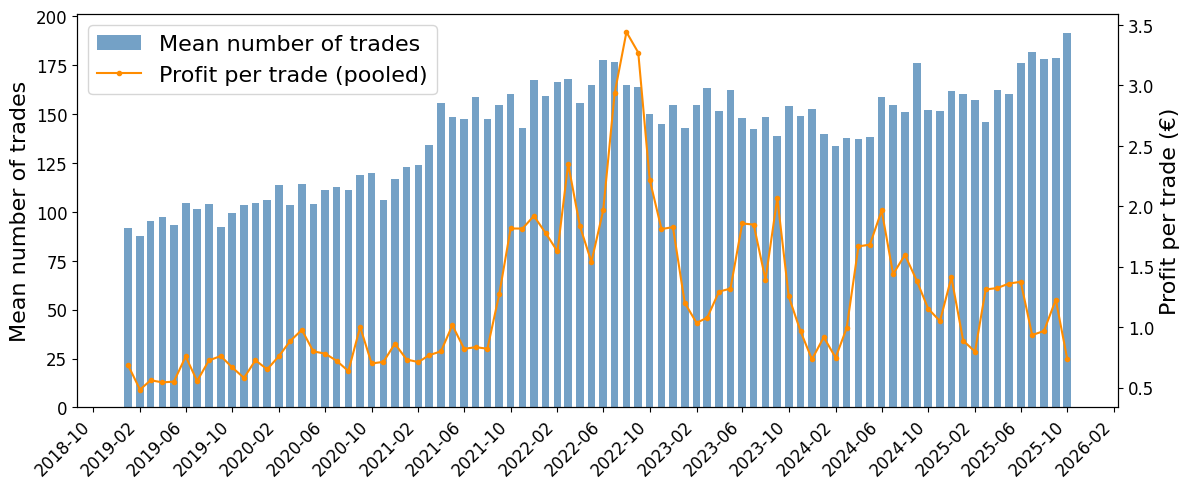

long rows 748800 monthly rows 82


,delivery_day,combo_id,n_trades,daily_profit,profit_per_trade,missing_file
0,2019-01-01 00:00:00+01:00,0,88.0,68.233139,0.775377,False
1,2019-01-01 00:00:00+01:00,1,86.0,44.266193,0.514723,False


In [ ]:
# Brute-Force merged trades: lange Tages×Kombi-Tabelle + monatliches Balken/Linien-Diagramm
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from coordinated_market_upper_bound_analysis.brute_force_trades_daily_long_and_plots import (
    build_long_table,
    monthly_aggregate,
    plot_monthly_bars_and_line,
)

_repo_bf = Path.cwd().resolve()
if _repo_bf.name == "evaluation":
    _repo_bf = _repo_bf.parent

BRUTE_FORCE_TRADES_DIR = _repo_bf / "coordinated_market_upper_bound_analysis" / "results_merged" / "trades"
BRUTE_FORCE_RESULTS_DIR = BRUTE_FORCE_TRADES_DIR.parent
BRUTE_FORCE_LONG_PARQUET = BRUTE_FORCE_RESULTS_DIR / "brute_force_daily_combo_trade_stats.parquet"
BRUTE_FORCE_LONG_CSV = BRUTE_FORCE_RESULTS_DIR / "brute_force_daily_combo_trade_stats.csv"
BRUTE_FORCE_MONTHLY_CSV = BRUTE_FORCE_RESULTS_DIR / "brute_force_monthly_trade_stats.csv"

REBUILD_BRUTE_FORCE_TRADE_LONG = False
BRUTE_FORCE_TRADE_WORKERS = 1
BRUTE_FORCE_PLOT_POOLED_LINE = True

plot_name_bf_trades = "brute_force_monthly_trades_and_profit_per_trade"

if REBUILD_BRUTE_FORCE_TRADE_LONG or (
    not BRUTE_FORCE_LONG_PARQUET.is_file() and not BRUTE_FORCE_LONG_CSV.is_file()
):
    if not BRUTE_FORCE_TRADES_DIR.is_dir():
        raise FileNotFoundError(
            f"Erwarteter Trades-Pfad fehlt (merged): {BRUTE_FORCE_TRADES_DIR}"
        )
    df_bf_trades_long = build_long_table(
        BRUTE_FORCE_TRADES_DIR,
        max_workers=max(1, int(BRUTE_FORCE_TRADE_WORKERS)),
    )
    BRUTE_FORCE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    try:
        df_bf_trades_long.to_parquet(BRUTE_FORCE_LONG_PARQUET, index=False)
    except ImportError:
        df_bf_trades_long.to_csv(BRUTE_FORCE_LONG_CSV, index=False)
else:
    if BRUTE_FORCE_LONG_PARQUET.is_file():
        df_bf_trades_long = pd.read_parquet(BRUTE_FORCE_LONG_PARQUET)
    else:
        df_bf_trades_long = pd.read_csv(
            BRUTE_FORCE_LONG_CSV,
            parse_dates=["delivery_day"],
        )

monthly_bf_trades = monthly_aggregate(df_bf_trades_long)
monthly_bf_trades.to_csv(BRUTE_FORCE_MONTHLY_CSV, index=False)

out_png_bf = Path(folder) / f"{plot_name_bf_trades}.png"
plot_monthly_bars_and_line(
    monthly_bf_trades,
    out_png_bf,
    use_pooled_line=BRUTE_FORCE_PLOT_POOLED_LINE,
    dpi=300,
    figsize=(12, 5),
    close_fig=False,
)
plt.show()

print("long rows", len(df_bf_trades_long), "monthly rows", len(monthly_bf_trades))
df_bf_trades_long.head(2)


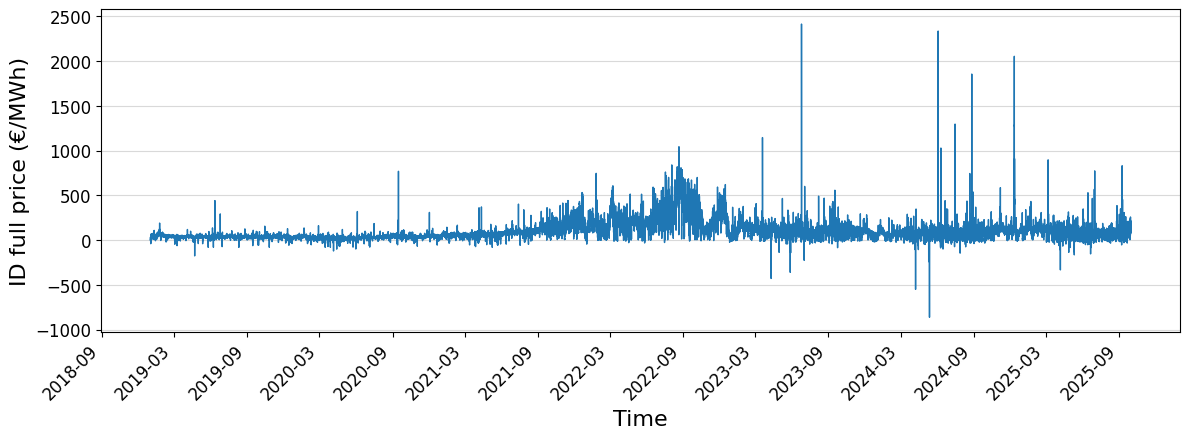

In [ ]:
# Hourly ID full price evolution
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

LABEL_FONTSIZE = 16
X_TICK_FONTSIZE = 12
Y_TICK_FONTSIZE = 12

_repo = Path.cwd().resolve()
if _repo.name == "evaluation":
    _repo = _repo.parent

hourly_csv = _repo / "data" / "data_2019-01-01_2025-09-30_hourly.csv"

df_id = pd.read_csv(hourly_csv, usecols=["time", "id_full_h"])
df_id["time"] = pd.to_datetime(df_id["time"], utc=True, errors="coerce")
df_id["id_full_h"] = pd.to_numeric(df_id["id_full_h"], errors="coerce")
df_id = df_id.dropna(subset=["time", "id_full_h"]).sort_values("time")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df_id["time"], df_id["id_full_h"], color="#1f77b4", lw=1.0)
ax.set_xlabel("Time", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("ID full price (€/MWh)", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis="x", which="major", labelsize=X_TICK_FONTSIZE)
ax.tick_params(axis="y", which="major", labelsize=Y_TICK_FONTSIZE)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m", tz=mdates.UTC))
ax.grid(axis="y", which="major", color="#D0D0D0", linestyle="-", linewidth=0.8, alpha=0.8)
ax.grid(axis="x", which="major", visible=False)
fig.autofmt_xdate(rotation=45)
fig.tight_layout()

plot_name = "id_full_h_price_evolution"
filepath = Path(folder) / f"{plot_name}.png"
plt.savefig(filepath, dpi=300, bbox_inches="tight")
plt.show()

/Users/timflaschel/Documents/GitHub/BessBidder1/coordinated_market_upper_bound_analysis/brute_force_trades_daily_long_and_plots.py:168: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  work["month"] = work["delivery_day"].dt.to_period("M").dt.to_timestamp(how="start")
/Users/timflaschel/Documents/GitHub/BessBidder1/coordinated_market_upper_bound_analysis/brute_force_trades_daily_long_and_plots.py:188: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_day = work.groupby("delivery_day", sort=True).apply(agg_day).reset_index()
/Users/timflaschel/Documents/GitHub/BessBidder1/coordinated_market_upper_bound_analysis/brute_force_trades_daily_long_and_plots.py:189: 

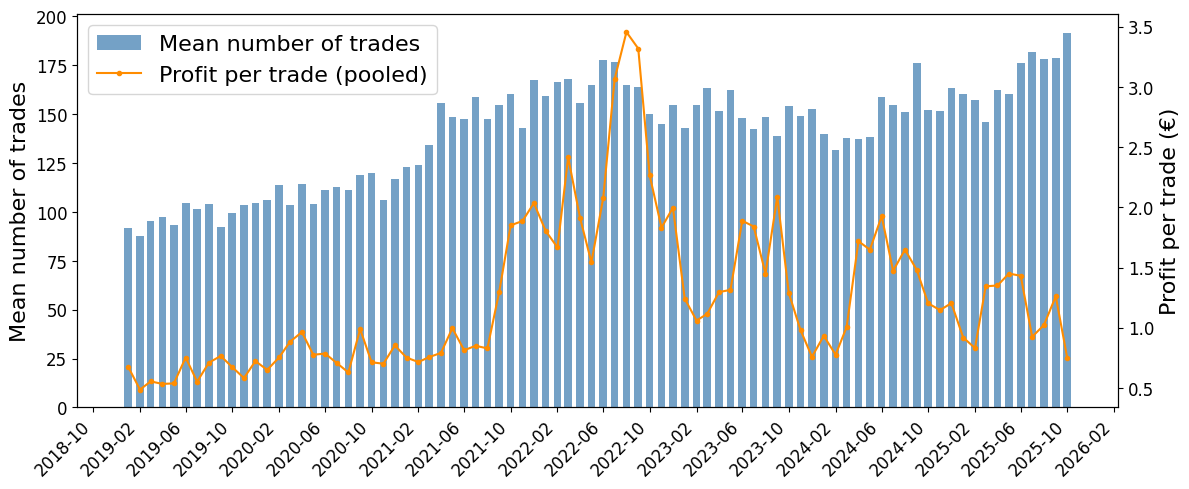

daily-first monthly rows 82


,month,mean_n_trades,mean_profit_per_trade,pooled_profit_per_trade,n_days,mean_day_rows,mean_day_rows_with_trades
79,2025-08-01,178.041505,1.028521,1.023022,31,300.0,300.0
80,2025-09-01,178.607444,1.269293,1.260805,30,300.0,300.0
81,2025-10-01,191.516559,0.753615,0.750654,31,300.0,300.0


In [ ]:
# Brute-Force merged trades: alternative aggregation (daily average first, then monthly average)
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from coordinated_market_upper_bound_analysis.brute_force_trades_daily_long_and_plots import (
    monthly_aggregate_daily_first,
    plot_monthly_bars_and_line,
)

_repo_bf = Path.cwd().resolve()
if _repo_bf.name == "evaluation":
    _repo_bf = _repo_bf.parent

BRUTE_FORCE_TRADES_DIR = _repo_bf / "coordinated_market_upper_bound_analysis" / "results_merged" / "trades"
BRUTE_FORCE_RESULTS_DIR = BRUTE_FORCE_TRADES_DIR.parent
BRUTE_FORCE_LONG_PARQUET = BRUTE_FORCE_RESULTS_DIR / "brute_force_daily_combo_trade_stats.parquet"
BRUTE_FORCE_LONG_CSV = BRUTE_FORCE_RESULTS_DIR / "brute_force_daily_combo_trade_stats.csv"
BRUTE_FORCE_MONTHLY_DAILY_FIRST_CSV = BRUTE_FORCE_RESULTS_DIR / "brute_force_monthly_trade_stats_daily_first.csv"

BRUTE_FORCE_PLOT_POOLED_LINE = True
plot_name_bf_trades_daily_first = "brute_force_monthly_trades_and_profit_per_trade_daily_first"

if BRUTE_FORCE_LONG_PARQUET.is_file():
    df_bf_trades_long = pd.read_parquet(BRUTE_FORCE_LONG_PARQUET)
elif BRUTE_FORCE_LONG_CSV.is_file():
    df_bf_trades_long = pd.read_csv(BRUTE_FORCE_LONG_CSV, parse_dates=["delivery_day"])
else:
    raise FileNotFoundError(
        "Kein Long-Cache gefunden. Bitte zuerst die vorherige Brute-Force-Zelle mit "
        "REBUILD_BRUTE_FORCE_TRADE_LONG=True ausführen."
    )

monthly_bf_trades_daily_first = monthly_aggregate_daily_first(df_bf_trades_long)
monthly_bf_trades_daily_first.to_csv(BRUTE_FORCE_MONTHLY_DAILY_FIRST_CSV, index=False)

out_png_bf_daily_first = Path(folder) / f"{plot_name_bf_trades_daily_first}.png"
plot_monthly_bars_and_line(
    monthly_bf_trades_daily_first,
    out_png_bf_daily_first,
    use_pooled_line=BRUTE_FORCE_PLOT_POOLED_LINE,
    dpi=300,
    figsize=(12, 5),
    close_fig=False,
)
plt.show()

print("daily-first monthly rows", len(monthly_bf_trades_daily_first))
monthly_bf_trades_daily_first.tail(3)


/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_70052/1862597148.py:77: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  x = monthly_bf["month"].dt.to_pydatetime()


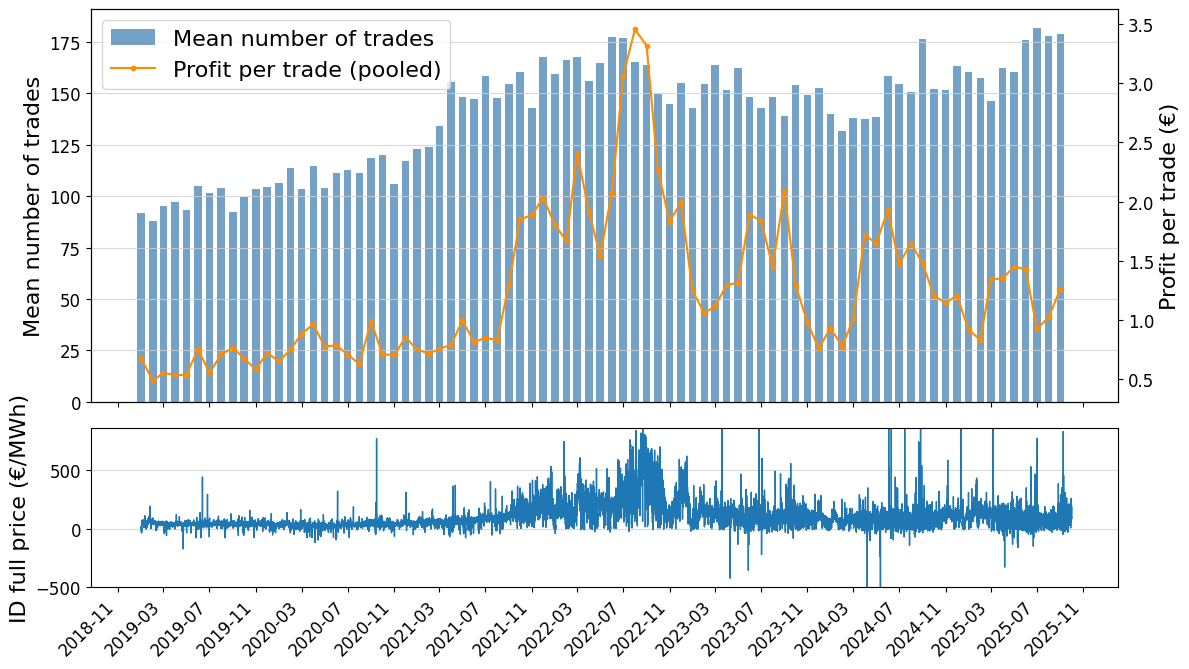

In [ ]:
# Combined view: daily-first brute-force monthly trades/profit + hourly ID full price
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coordinated_market_upper_bound_analysis.brute_force_trades_daily_long_and_plots import (
    monthly_aggregate_daily_first,
)

LABEL_FONTSIZE = 16
X_TICK_FONTSIZE = 12
Y_TICK_FONTSIZE = 12

OUTLIER_PCT_LOW = 0.005
OUTLIER_PCT_HIGH = 99.95
Y_PAD_FRAC = 0.06


def _robust_ylim(values: pd.Series, low_pct: float = OUTLIER_PCT_LOW, high_pct: float = OUTLIER_PCT_HIGH):
    s = pd.to_numeric(values, errors="coerce").dropna()
    if s.empty:
        return None
    lo, hi = np.percentile(s.to_numpy(dtype=float), [low_pct, high_pct])
    span = float(hi - lo)
    if not np.isfinite(span):
        return None
    if span <= 0:
        span = max(abs(float(lo)), 1.0) * 0.05
        lo, hi = lo - span, hi + span
    pad = span * Y_PAD_FRAC
    return float(lo - pad), float(hi + pad)


_repo = Path.cwd().resolve()
if _repo.name == "evaluation":
    _repo = _repo.parent

# 1) Monthly brute-force stats (daily-first logic), loaded from CSV if available
_bf_results_dir = _repo / "coordinated_market_upper_bound_analysis" / "results_merged"
_monthly_daily_first_csv = _bf_results_dir / "brute_force_monthly_trade_stats_daily_first.csv"
_long_parquet = _bf_results_dir / "brute_force_daily_combo_trade_stats.parquet"
_long_csv = _bf_results_dir / "brute_force_daily_combo_trade_stats.csv"

if _monthly_daily_first_csv.is_file():
    monthly_bf = pd.read_csv(_monthly_daily_first_csv, parse_dates=["month"])
else:
    if _long_parquet.is_file():
        _long = pd.read_parquet(_long_parquet)
    elif _long_csv.is_file():
        _long = pd.read_csv(_long_csv, parse_dates=["delivery_day"])
    else:
        raise FileNotFoundError(
            "No brute-force monthly/long cache found. Run the previous brute-force cells first."
        )
    monthly_bf = monthly_aggregate_daily_first(_long)

monthly_bf = monthly_bf.sort_values("month").reset_index(drop=True)

# 2) Hourly ID full price (no monthly smoothing)
_hourly_csv = _repo / "data" / "data_2019-01-01_2025-09-30_hourly.csv"
df_id = pd.read_csv(_hourly_csv, usecols=["time", "id_full_h"])
df_id["time"] = pd.to_datetime(df_id["time"], utc=True, errors="coerce")
# Make timestamps tz-naive to match monthly_bf['month'] dtype for min/max comparisons.
df_id["time"] = df_id["time"].dt.tz_localize(None)
df_id["id_full_h"] = pd.to_numeric(df_id["id_full_h"], errors="coerce")
df_id = df_id.dropna(subset=["time", "id_full_h"]).sort_values("time")

# Align x-range for both subplots
x_min = max(monthly_bf["month"].min(), df_id["time"].min())
x_max = min(monthly_bf["month"].max(), df_id["time"].max())
monthly_bf = monthly_bf[(monthly_bf["month"] >= x_min) & (monthly_bf["month"] <= x_max)]
df_id = df_id[(df_id["time"] >= x_min) & (df_id["time"] <= x_max)]

x = monthly_bf["month"].dt.to_pydatetime()

# Layout: top main panel + slim price panel below
fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(12, 6.8),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1.3]},
)

# Top: bars + pooled profit per trade line
ax_top.bar(
    x,
    monthly_bf["mean_n_trades"],
    width=20,
    color="steelblue",
    alpha=0.75,
    label="Mean number of trades",
)
ax_top.set_ylabel("Mean number of trades", fontsize=LABEL_FONTSIZE)
ax_top.tick_params(axis="y", which="major", labelsize=Y_TICK_FONTSIZE)

ax_top_r = ax_top.twinx()
ax_top_r.plot(
    x,
    monthly_bf["pooled_profit_per_trade"],
    color="darkorange",
    marker="o",
    lw=1.5,
    ms=3,
    label="Profit per trade (pooled)",
)
ax_top_r.set_ylabel("Profit per trade (€)", fontsize=LABEL_FONTSIZE)
ax_top_r.tick_params(axis="y", which="major", labelsize=Y_TICK_FONTSIZE)

_ylim_top_right = _robust_ylim(monthly_bf["pooled_profit_per_trade"])
if _ylim_top_right is not None:
    ax_top_r.set_ylim(_ylim_top_right)

h1, l1 = ax_top.get_legend_handles_labels()
h2, l2 = ax_top_r.get_legend_handles_labels()
ax_top.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=LABEL_FONTSIZE, frameon=True)

# Bottom: ID full hourly price (global outlier clipping only on y-axis limits)
ax_bottom.plot(df_id["time"], df_id["id_full_h"], color="#1f77b4", lw=1.0)
ax_bottom.set_ylabel("ID full price (€/MWh)", fontsize=LABEL_FONTSIZE)
ax_bottom.tick_params(axis="y", which="major", labelsize=Y_TICK_FONTSIZE)
ax_bottom.tick_params(axis="x", which="major", labelsize=X_TICK_FONTSIZE)

_ylim_bottom = _robust_ylim(df_id["id_full_h"])
if _ylim_bottom is not None:
    ax_bottom.set_ylim(_ylim_bottom)

# Shared x-axis styling (months only; no x-axis label)
ax_bottom.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_bottom.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
fig.autofmt_xdate(rotation=45)

for _ax in (ax_top, ax_bottom):
    _ax.grid(axis="y", which="major", color="#D0D0D0", linestyle="-", linewidth=0.8, alpha=0.8)
    _ax.grid(axis="x", which="major", visible=False)

fig.tight_layout()
plot_name = "brute_force_monthly_trades_profit_and_id_full_price"
filepath = Path(folder) / f"{plot_name}.png"
plt.savefig(filepath, dpi=300, bbox_inches="tight")
plt.show()

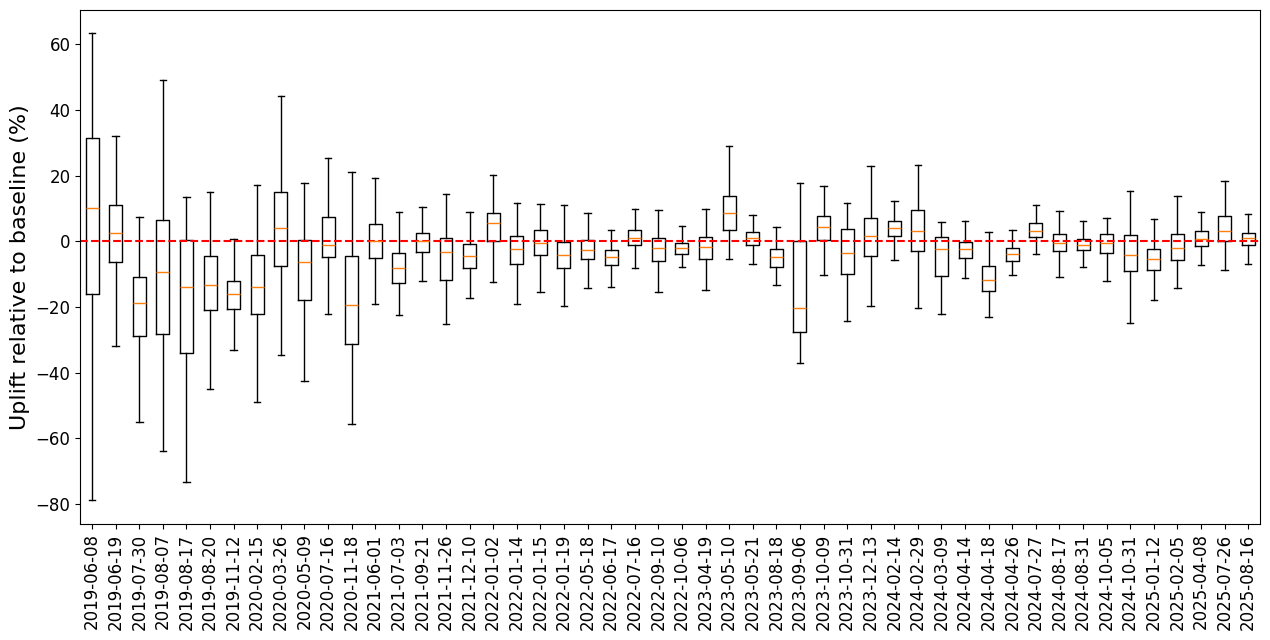

(50, ['2019-06-08', '2019-06-19', '2019-07-30'])

In [ ]:
# Random-day boxplots: % uplift vs intraday baseline from brute-force summary_*.csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

LABEL_FONTSIZE = 16
TICK_FONTSIZE = 12

N_RANDOM_DAYS = 50  # choose between 20 and 30
RANDOM_SEED = 42
MIN_ABS_BASELINE_PROFIT = 1e-9

_repo = Path.cwd().resolve()
if _repo.name == "evaluation":
    _repo = _repo.parent

summary_dir = _repo / "coordinated_market_upper_bound_analysis" / "results_merged"
summary_files = sorted(summary_dir.glob("summary_*.csv"))
if not summary_files:
    raise FileNotFoundError(f"No summary_*.csv files found under: {summary_dir}")

n_pick = min(N_RANDOM_DAYS, len(summary_files))
rng = np.random.default_rng(RANDOM_SEED)
picked_idx = rng.choice(len(summary_files), size=n_pick, replace=False)
picked_files = [summary_files[i] for i in sorted(picked_idx)]

labels: list[str] = []
box_data: list[np.ndarray] = []

for fp in picked_files:
    df = pd.read_csv(fp, usecols=["profit"])
    profit = pd.to_numeric(df["profit"], errors="coerce")
    if profit.empty:
        continue

    baseline = float(profit.iloc[0])  # first row = pure intraday baseline
    if not np.isfinite(baseline) or abs(baseline) <= MIN_ABS_BASELINE_PROFIT:
        continue

    # Compare all combinations except baseline row to baseline in percent.
    vals = ((profit.iloc[1:] - baseline) / abs(baseline) * 100.0).dropna().to_numpy(dtype=float)
    if vals.size == 0:
        continue

    labels.append(fp.stem.replace("summary_", ""))
    box_data.append(vals)

if not box_data:
    raise RuntimeError("No valid daily boxplot data could be created (baseline may be zero/NaN).")

fig, ax = plt.subplots(figsize=(12.8, 6.5))
ax.boxplot(
    box_data,
    patch_artist=False,
    widths=0.55,
    showfliers=False,  # hide outlier points; keep whisker/cap "T-bars"
)
ax.axhline(0.0, color="red", linestyle="--", linewidth=1.5)

ax.set_ylabel("Uplift relative to baseline (%)", fontsize=LABEL_FONTSIZE)
ax.set_xlabel("")  # no x-axis label requested
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=90)
ax.tick_params(axis="x", which="major", labelsize=TICK_FONTSIZE)
ax.tick_params(axis="y", which="major", labelsize=TICK_FONTSIZE)
# No inner grid lines requested.

fig.tight_layout()
plot_name = "brute_force_random_days_uplift_boxplots"
filepath = Path(folder) / f"{plot_name}.png"
plt.savefig(filepath, dpi=300, bbox_inches="tight")
plt.show()

len(box_data), labels[:3]
